# BIST-100 Güniçi Scalp Trading: TA + GARCH + XGBoost Şampiyon Strateji Motoru

**Mimari:** Özellik Mühendisliği → Üç Bağımsız Strateji Motoru → Vektörel Backtest → Kıyaslama & Şampiyon İlanı

| Katman | Açıklama |
|--------|----------|
| Veri | yfinance ile 1d/1h/15m OHLCV + XU100 endeks verisi |
| Strateji A | RSI-14 + MACD sinyal kesişimi (kural tabanlı TA) |
| Strateji B | GARCH(1,1) koşullu oynaklık eşik filtresi |
| Strateji C | XGBoost sınıflandırıcı (teknik + göreceli özellikler) |
| Backtest | Kronolojik %20 test seti, vektörel hesaplama |
| Metrikler | Getiri, Sharpe, MaxDD, Win Rate, Calmar |

In [1]:
# Gerekli kütüphaneleri kur
import subprocess, sys

pkgs = [
    'git+https://github.com/rongardF/tvdatafeed.git',
    'arch', 'xgboost', 'ta', 'matplotlib', 'seaborn',
    'scikit-learn', 'optuna', 'joblib',
]
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=False)

print('Kurulum tamamlandı.')


Kurulum tamamlandı.


In [2]:
import warnings, json, os, hashlib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path

# TradingView veri kaynağı
from tvDatafeed import TvDatafeed, Interval

# İstatistik & ML
from arch import arch_model
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Teknik analiz
import ta

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('dark_background')
COLORS = ['#00ff88', '#ff6b6b', '#4ecdc4', '#ffd93d', '#c77dff']

# Hafıza dosyaları (modeli ve geçmiş performansı saklar)
MEMORY_DIR   = Path('bist_memory')
MEMORY_DIR.mkdir(exist_ok=True)
MODEL_FILE   = MEMORY_DIR / 'xgb_model.pkl'
SCALER_FILE  = MEMORY_DIR / 'scaler.pkl'
HISTORY_FILE = MEMORY_DIR / 'performance_history.json'
PARAMS_FILE  = MEMORY_DIR / 'best_params.json'

print('Tüm kütüphaneler yüklendi ✓')
print(f'Hafıza klasörü: {MEMORY_DIR.resolve()}')


Tüm kütüphaneler yüklendi ✓
Hafıza klasörü: /content/bist_memory


## ⚙️ KONFIGÜRASYON — Hisseyi, Zaman Dilimini ve Parametreleri Buradan Ayarla

In [3]:
# ═══════════════════════════════════════════════════════════════
#  KULLANICI AYARLARI  — sadece bu bloğu değiştir
# ═══════════════════════════════════════════════════════════════

# TradingView sembol ve borsa adı (tvdatafeed formatı)
TICKER        = 'THYAO'          # TradingView sembol adı (büyük harf, .IS eki olmadan)
INDEX_TKR     = 'XU100'          # Endeks sembol adı
EXCHANGE      = 'BIST'           # Borsa adı (TradingView'deki gibi)
INDEX_EXCHANGE= 'BIST'

# TradingView oturum açma (opsiyonel — boş bırakılırsa misafir erişim kullanılır)
TV_USERNAME   = ''               # TradingView kullanıcı adı (boş bırakılabilir)
TV_PASSWORD   = ''               # TradingView şifresi     (boş bırakılabilir)

# Zaman dilimi → Interval enum eşlemesi
# Seçenekler: '1m','3m','5m','15m','30m','45m','1h','2h','3h','4h','1d','1W','1M'
INTERVAL_STR  = '1h'

TV_INTERVAL_MAP = {
    '1m' : Interval.in_1_minute,
    '3m' : Interval.in_3_minute,
    '5m' : Interval.in_5_minute,
    '15m': Interval.in_15_minute,
    '30m': Interval.in_30_minute,
    '45m': Interval.in_45_minute,
    '1h' : Interval.in_1_hour,
    '2h' : Interval.in_2_hour,
    '3h' : Interval.in_3_hour,
    '4h' : Interval.in_4_hour,
    '1d' : Interval.in_daily,
    '1W' : Interval.in_weekly,
    '1M' : Interval.in_monthly,
}
TV_INTERVAL = TV_INTERVAL_MAP[INTERVAL_STR]
INTERVAL    = INTERVAL_STR   # backtest annualize faktörü için

# Kaç bar çekilsin
N_BARS        = 5000           # tvdatafeed maksimum bar sayısı

# Teknik parametreler
RSI_PERIOD   = 14
MACD_FAST    = 12
MACD_SLOW    = 26
MACD_SIGNAL  = 9
VOL_MA_WIN   = 20

# GARCH oynaklık eşiği (yüzdelik dilim)
GARCH_THRESH_LOW  = 30
GARCH_THRESH_HIGH = 70

# XGBoost
TRAIN_RATIO  = 0.80
XGB_PARAMS   = dict(
    n_estimators=400, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

# Backtest
TRANSACTION_COST = 0.001
INITIAL_CAPITAL  = 100_000

print(f'Konfigürasyon: {TICKER} ({EXCHANGE}) | {INTERVAL_STR} | {N_BARS} bar')


Konfigürasyon: THYAO (BIST) | 1h | 5000 bar


## 📥 1. VERİ İNDİRME

In [4]:
def get_tv_client() -> TvDatafeed:
    """TvDatafeed istemcisini oluştur. Kullanıcı adı/şifre boşsa misafir modda çalışır."""
    if TV_USERNAME and TV_PASSWORD:
        tv = TvDatafeed(TV_USERNAME, TV_PASSWORD)
        print('TradingView oturumu açıldı ✓')
    else:
        tv = TvDatafeed()
        print('TradingView misafir modda bağlandı ✓ (giriş yapılmadı)')
    return tv


def tv_to_df(raw: pd.DataFrame) -> pd.DataFrame:
    """
    tvdatafeed çıktısını standart OHLCV DataFrame'e dönüştür.
    tvdatafeed sütun adları: symbol, open, high, low, close, volume
    """
    df = raw.copy()
    df.index = pd.to_datetime(df.index)
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

    # Sütun adlarını büyük harfe çevir
    df.columns = [c.capitalize() for c in df.columns]

    # 'Symbol' sütunu varsa düşür (tvdatafeed ekler)
    if 'Symbol' in df.columns:
        df.drop(columns=['Symbol'], inplace=True)

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.sort_index(inplace=True)
    df.dropna(subset=['Close'], inplace=True)
    return df


def download_data(ticker: str, exchange: str,
                  index_ticker: str, index_exchange: str,
                  interval: Interval, n_bars: int) -> pd.DataFrame:
    """
    tvdatafeed ile hisse + endeks verisini çek, birleştir ve temizle.
    """
    tv = get_tv_client()

    print(f'▶ {ticker} ({exchange}) indiriliyor...')
    raw_stock = tv.get_hist(
        symbol=ticker, exchange=exchange,
        interval=interval, n_bars=n_bars
    )
    if raw_stock is None or raw_stock.empty:
        raise ValueError(f'{ticker} için veri alınamadı. Sembol/borsa adını kontrol et.')

    print(f'▶ {index_ticker} ({index_exchange}) indiriliyor...')
    raw_index = tv.get_hist(
        symbol=index_ticker, exchange=index_exchange,
        interval=interval, n_bars=n_bars
    )

    df = tv_to_df(raw_stock)

    if raw_index is not None and not raw_index.empty:
        idx = tv_to_df(raw_index)
        df['Endeks_Close'] = idx['Close'].reindex(df.index, method='ffill')
    else:
        print('Uyarı: Endeks verisi alınamadı, hisse fiyatı kullanılıyor.')
        df['Endeks_Close'] = df['Close']

    print(f'✓ {len(df):,} bar yüklendi | {df.index[0].date()} → {df.index[-1].date()}')
    return df


# Veriyi çek
df_raw = download_data(
    TICKER, EXCHANGE,
    INDEX_TKR, INDEX_EXCHANGE,
    TV_INTERVAL, N_BARS
)
df_raw.tail()


TradingView misafir modda bağlandı ✓ (giriş yapılmadı)
▶ THYAO (BIST) indiriliyor...
▶ XU100 (BIST) indiriliyor...
✓ 5,000 bar yüklendi | 2024-06-27 → 2026-07-01


,Open,High,Low,Close,Volume,Endeks_Close
datetime,,,,,,
2026-06-30 14:00:00,325.7500,326.5000,324.7500,326.2500,13044534.0000,14114.6600
2026-06-30 15:00:00,326.2500,326.2500,326.0000,326.0000,2140735.0000,14121.8300
2026-07-01 06:00:00,325.7500,325.7500,325.7500,325.7500,121559.0000,14110.4600
2026-07-01 07:00:00,325.5000,331.0000,323.0000,330.5000,16480513.0000,14198.1200
2026-07-01 08:00:00,330.2500,330.7500,329.7500,330.2500,2373262.0000,14210.5700


## 🔧 2. ÖZELLİK MÜHENDİSLİĞİ & HEDEF TANIMLAMA

In [5]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tüm teknik ve istatistiksel özellikleri hesapla."""
    d = df.copy()

    # ── Temel getiri ──────────────────────────────────────────────
    d['Log_Return']  = np.log(d['Close'] / d['Close'].shift(1))
    d['Next_Return'] = d['Log_Return'].shift(-1)   # hedef için
    d['Label']       = (d['Next_Return'] > 0).astype(int)

    # ── RSI ───────────────────────────────────────────────────────
    d['RSI'] = ta.momentum.RSIIndicator(close=d['Close'], window=RSI_PERIOD).rsi()

    # ── MACD ──────────────────────────────────────────────────────
    macd_obj = ta.trend.MACD(
        close=d['Close'],
        window_slow=MACD_SLOW,
        window_fast=MACD_FAST,
        window_sign=MACD_SIGNAL
    )
    d['MACD']        = macd_obj.macd()
    d['MACD_Signal'] = macd_obj.macd_signal()
    d['MACD_Hist']   = macd_obj.macd_diff()

    # ── Hareketli Ortalamalar ─────────────────────────────────────
    d['EMA9']  = ta.trend.EMAIndicator(d['Close'], window=9).ema_indicator()
    d['EMA21'] = ta.trend.EMAIndicator(d['Close'], window=21).ema_indicator()
    d['SMA50'] = ta.trend.SMAIndicator(d['Close'], window=50).sma_indicator()
    d['SMA200']= ta.trend.SMAIndicator(d['Close'], window=200).sma_indicator()

    # ── Bollinger Bantları ────────────────────────────────────────
    bb = ta.volatility.BollingerBands(d['Close'], window=20, window_dev=2)
    d['BB_High'] = bb.bollinger_hband()
    d['BB_Low']  = bb.bollinger_lband()
    d['BB_Width']= bb.bollinger_wband()
    d['BB_Pct']  = bb.bollinger_pband()   # 0–1 arası pozisyon

    # ── ATR (Average True Range) ──────────────────────────────────
    d['ATR'] = ta.volatility.AverageTrueRange(
        d['High'], d['Low'], d['Close'], window=14
    ).average_true_range()
    d['ATR_Pct'] = d['ATR'] / d['Close']  # normalize

    # ── Stokastik ─────────────────────────────────────────────────
    stoch = ta.momentum.StochasticOscillator(d['High'], d['Low'], d['Close'], window=14, smooth_window=3)
    d['Stoch_K'] = stoch.stoch()
    d['Stoch_D'] = stoch.stoch_signal()

    # ── Hacim Özellikleri ─────────────────────────────────────────
    d['Vol_MA']     = d['Volume'].rolling(VOL_MA_WIN).mean()
    d['Vol_Ratio']  = d['Volume'] / d['Vol_MA']        # hacim baskısı
    d['OBV']        = ta.volume.OnBalanceVolumeIndicator(d['Close'], d['Volume']).on_balance_volume()
    d['OBV_EMA']    = d['OBV'].ewm(span=20).mean()
    d['OBV_Signal'] = (d['OBV'] > d['OBV_EMA']).astype(int)

    # ── Endeks Göreceli Gücü ──────────────────────────────────────
    d['Relative_Strength'] = d['Close'] / d['Endeks_Close']
    d['RS_Momentum']       = d['Relative_Strength'].pct_change(5)  # 5 bar RS değişimi

    # ── Momentum / ROC ────────────────────────────────────────────
    d['ROC5']  = ta.momentum.ROCIndicator(d['Close'], window=5).roc()
    d['ROC10'] = ta.momentum.ROCIndicator(d['Close'], window=10).roc()
    d['ROC20'] = ta.momentum.ROCIndicator(d['Close'], window=20).roc()

    # ── Trend Gücü ────────────────────────────────────────────────
    adx = ta.trend.ADXIndicator(d['High'], d['Low'], d['Close'], window=14)
    d['ADX']   = adx.adx()
    d['DI_pos']= adx.adx_pos()
    d['DI_neg']= adx.adx_neg()

    # ── Fiyat Pattern Özellikleri ─────────────────────────────────
    d['Body_Size']   = abs(d['Close'] - d['Open']) / (d['High'] - d['Low'] + 1e-9)
    d['Upper_Wick']  = (d['High'] - d[['Close','Open']].max(axis=1)) / (d['High'] - d['Low'] + 1e-9)
    d['Lower_Wick']  = (d[['Close','Open']].min(axis=1) - d['Low']) / (d['High'] - d['Low'] + 1e-9)
    d['Bullish_Bar'] = (d['Close'] > d['Open']).astype(int)

    # ── Gecikme (Lag) Özellikleri ─────────────────────────────────
    for lag in [1, 2, 3, 5]:
        d[f'Ret_lag{lag}'] = d['Log_Return'].shift(lag)
        d[f'RSI_lag{lag}'] = d['RSI'].shift(lag)

    # ── Güniçi Volatilite ─────────────────────────────────────────
    d['Intraday_Range'] = (d['High'] - d['Low']) / d['Open']
    d['Gap_Pct']        = (d['Open'] - d['Close'].shift(1)) / d['Close'].shift(1)

    return d


df = build_features(df_raw)
print(f'Özellik sayısı: {df.shape[1]} | Satır: {df.shape[0]:,}')
df[['Close','RSI','MACD','MACD_Signal','ATR_Pct','Vol_Ratio','Label']].tail(10)

Özellik sayısı: 52 | Satır: 5,000


,Close,RSI,MACD,MACD_Signal,ATR_Pct,Vol_Ratio,Label
datetime,,,,,,,
2026-06-30 09:00:00,326.5000,41.9165,-0.1781,0.0313,0.0053,0.9147,1
2026-06-30 10:00:00,326.7500,43.1845,-0.2759,-0.0301,0.0052,0.6803,0
2026-06-30 11:00:00,325.7500,39.4725,-0.4291,-0.1099,0.0052,0.8423,0
2026-06-30 12:00:00,325.5000,38.5797,-0.5642,-0.2008,0.0053,1.2993,1
2026-06-30 13:00:00,325.7500,40.0402,-0.6437,-0.2894,0.0052,1.1034,1
2026-06-30 14:00:00,326.2500,42.9616,-0.6588,-0.3633,0.0052,2.9445,0
2026-06-30 15:00:00,326.0000,41.8633,-0.6830,-0.4272,0.0049,0.4772,0
2026-07-01 06:00:00,325.7500,40.7416,-0.7142,-0.4846,0.0046,0.0271,1
2026-07-01 07:00:00,330.5000,61.7250,-0.3515,-0.4580,0.0059,3.4092,0


## 🏗️ 3. STRATEJİ MOTORLARI

In [6]:
# ══════════════════════════════════════════════════════════════════
#  STRATEJİ A — Klasik TA  (sadece AL=1 veya BEKLE=0)
#  Short/long yok. Sinyal 1 ise pozisyon aç, 0 ise nakitte bekle.
# ══════════════════════════════════════════════════════════════════

def strategy_A_signals(df: pd.DataFrame) -> pd.Series:
    hist = df['MACD_Hist']
    macd_cross_up = (hist > 0) & (hist.shift(1) <= 0)   # histogram sıfırı yukarı kesti

    rsi_ok    = (df['RSI'] > 40) & (df['RSI'] < 70)     # aşırı alım bölgesinde değil
    trend_up  = df['EMA9'] > df['EMA21']                 # kısa vade yukarı
    vol_ok    = df['Vol_Ratio'] > 1.0                    # ortalamanın üzerinde hacim
    adx_ok    = df['ADX'] > 20                           # belirgin trend var

    sig = pd.Series(0, index=df.index)
    sig[macd_cross_up & rsi_ok & trend_up & vol_ok] = 1  # AL

    # Çıkış: MACD histogram negatife geçti → nakde dön
    macd_cross_dn = (hist < 0) & (hist.shift(1) >= 0)
    sig[macd_cross_dn] = 0  # zaten 0, ama açık bırakmak için

    # Pozisyonu koru: AL sinyali geldi, henüz çıkış sinyali gelmediyse tut
    position = pd.Series(0, index=df.index)
    in_trade = False
    for i in range(len(sig)):
        if sig.iloc[i] == 1:
            in_trade = True
        elif macd_cross_dn.iloc[i] or df['EMA9'].iloc[i] < df['EMA21'].iloc[i]:
            in_trade = False
        position.iloc[i] = 1 if in_trade else 0

    return position

print('Strateji A (Klasik TA) — sadece AL/BEKLE ✓')


Strateji A (Klasik TA) — sadece AL/BEKLE ✓


In [7]:
# ══════════════════════════════════════════════════════════════════
#  STRATEJİ B — GARCH(1,1)  (sadece AL=1 veya BEKLE=0)
#  Düşük oynaklık + yükseliş yönü = AL
#  Yüksek oynaklık veya düşüş yönü = BEKLE (nakitte kal)
# ══════════════════════════════════════════════════════════════════

def strategy_B_signals(df: pd.DataFrame,
                        thresh_low:  float = GARCH_THRESH_LOW,
                        thresh_high: float = GARCH_THRESH_HIGH) -> pd.Series:
    returns = df['Log_Return'].dropna() * 100

    try:
        model  = arch_model(returns, vol='Garch', p=1, q=1, dist='Normal', rescale=False)
        result = model.fit(disp='off', options={'maxiter': 500})
        cond_vol = result.conditional_volatility
    except Exception as e:
        print(f'GARCH fit hatası: {e}. Rolling std kullanılıyor.')
        cond_vol = returns.rolling(20).std()

    vol_pct = cond_vol.rolling(252, min_periods=50).rank(pct=True) * 100
    vol_pct = vol_pct.reindex(df.index)

    low_vol  = vol_pct < thresh_low    # sıkışma bölgesi → kırılım bekle
    high_vol = vol_pct > thresh_high   # kaotik dönem   → kenarda kal

    # Yalnızca yükseliş yönü sinyali
    bullish = ((df['RSI'] > 50) & (df['MACD_Hist'] > 0) & (df['EMA9'] > df['EMA21']))

    sig = pd.Series(0, index=df.index)
    sig[low_vol & bullish]  = 1   # düşük vol + yükseliş = AL
    sig[high_vol]           = 0   # yüksek vol = nakitte kal

    df['GARCH_Vol']     = cond_vol.reindex(df.index)
    df['GARCH_Vol_Pct'] = vol_pct
    return sig

print('Strateji B (GARCH) — sadece AL/BEKLE ✓')


Strateji B (GARCH) — sadece AL/BEKLE ✓


In [8]:
# ══════════════════════════════════════════════════════════════════
#  STRATEJİ C — XGBoost Sınıflandırıcı
# ══════════════════════════════════════════════════════════════════

FEATURE_COLS = [
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'EMA9', 'EMA21', 'BB_Pct', 'BB_Width',
    'ATR_Pct', 'Stoch_K', 'Stoch_D',
    'Vol_Ratio', 'OBV_Signal',
    'Relative_Strength', 'RS_Momentum',
    'ROC5', 'ROC10', 'ROC20',
    'ADX', 'DI_pos', 'DI_neg',
    'Body_Size', 'Upper_Wick', 'Lower_Wick', 'Bullish_Bar',
    'Ret_lag1', 'Ret_lag2', 'Ret_lag3', 'Ret_lag5',
    'RSI_lag1', 'RSI_lag2', 'RSI_lag3',
    'Intraday_Range', 'Gap_Pct',
]

def strategy_C_train_predict(df: pd.DataFrame, train_ratio: float = TRAIN_RATIO):
    """
    Kronolojik bölme: train_ratio kadarı eğitim, kalanı test.
    Döndürür: (sinyaller, test_start_idx, model, scaler, feature_importance)
    """
    avail_cols = [c for c in FEATURE_COLS if c in df.columns]
    dfc = df[avail_cols + ['Label']].dropna().copy()

    split_n    = int(len(dfc) * train_ratio)
    train_data = dfc.iloc[:split_n]
    test_data  = dfc.iloc[split_n:]

    X_train, y_train = train_data[avail_cols], train_data['Label']
    X_test,  y_test  = test_data[avail_cols],  test_data['Label']

    scaler  = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # Sınıf dengesi için ağırlık
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    model = XGBClassifier(**XGB_PARAMS, scale_pos_weight=pos_weight)
    model.fit(
        X_train_sc, y_train,
        eval_set=[(X_test_sc, y_test)],
        verbose=False
    )

    preds_train = model.predict(X_train_sc)
    preds_test  = model.predict(X_test_sc)
    proba_test  = model.predict_proba(X_test_sc)[:, 1]

    train_acc = accuracy_score(y_train, preds_train)
    test_acc  = accuracy_score(y_test,  preds_test)
    print(f'XGBoost | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}')
    print(f'Test dönemi: {test_data.index[0].date()} → {test_data.index[-1].date()} ({len(test_data):,} bar)')

    # Sinyal serisi: test döneminde tahminleri al, geri kalanı 0
    sig = pd.Series(0, index=df.index)
    # 1 = al tahmini, 0 = sat/bekle tahmini → -1 olarak kodla
    sig.loc[test_data.index] = np.where(preds_test == 1, 1, 0)   # 1=AL, 0=nakitte bekle

    feat_imp = pd.Series(model.feature_importances_, index=avail_cols).sort_values(ascending=False)

    return sig, test_data.index[0], model, scaler, feat_imp, test_acc


print('Strateji C (XGBoost) fonksiyonu tanımlandı ✓')

Strateji C (XGBoost) fonksiyonu tanımlandı ✓


## 🚀 4. STRATEJİLERİ ÇALIŞTIR

In [9]:
print('═'*60)
print('STRATEJİLER HESAPLANIYOR...')
print('═'*60)

# Strateji A
print('\n[A] Klasik TA sinyalleri hesaplanıyor...')
sig_A = strategy_A_signals(df)
print(f'    Sinyal dağılımı: Al={( sig_A==1).sum()} | Sat={(sig_A==-1).sum()} | Bekle={(sig_A==0).sum()}')

# Strateji B
print('\n[B] GARCH(1,1) fit ediliyor...')
sig_B = strategy_B_signals(df)
print(f'    Sinyal dağılımı: Al={( sig_B==1).sum()} | Sat={(sig_B==-1).sum()} | Bekle={(sig_B==0).sum()}')

# Strateji C
print('\n[C] XGBoost eğitiliyor...')
sig_C, test_start, xgb_model, xgb_scaler, feat_imp, xgb_test_acc = strategy_C_train_predict(df)

print(f'\n✓ Tüm stratejiler hazır. Test dönemi başlangıcı: {test_start}')

════════════════════════════════════════════════════════════
STRATEJİLER HESAPLANIYOR...
════════════════════════════════════════════════════════════

[A] Klasik TA sinyalleri hesaplanıyor...
    Sinyal dağılımı: Al=334 | Sat=0 | Bekle=4666

[B] GARCH(1,1) fit ediliyor...
    Sinyal dağılımı: Al=484 | Sat=0 | Bekle=4516

[C] XGBoost eğitiliyor...
XGBoost | Train Acc: 0.872 | Test Acc: 0.533
Test dönemi: 2026-01-30 → 2026-07-01 (994 bar)

✓ Tüm stratejiler hazır. Test dönemi başlangıcı: 2026-01-30 13:00:00


## 📊 5. BACKTEST & KIYASLAMA MOTORU

In [10]:
def run_backtest(df: pd.DataFrame, signals: pd.Series, strategy_name: str,
                 start_date=None, cost: float = TRANSACTION_COST) -> dict:
    """
    Vektörel backtest motoru.
    - Sinyal 1  → uzun pozisyon (bir sonraki barda giriş)
    - Sinyal -1 → kısa pozisyon (BIST'te CFD/Vadeli ile uygulanabilir; spot için 0 al)
    - Sinyal 0  → nakit
    """
    data = df.copy()
    data['Signal'] = signals

    # Test dönemine kırp
    if start_date is not None:
        data = data[data.index >= start_date]

    data = data.dropna(subset=['Log_Return'])

    # Bir sonraki barda işlem yap (look-ahead bias önlemi)
    # BIST spot: -1 (SAT) = nakde geç (açığa satış yok) → clip(0,1)
    data['Position'] = data['Signal'].shift(1).fillna(0).clip(0, 1)

    # Ham getiri (pozisyon × bar getirisi)
    data['Strat_Return'] = data['Position'] * data['Log_Return']

    # İşlem maliyeti: pozisyon değiştiğinde uygula
    pos_change = data['Position'].diff().abs()
    data['Cost'] = pos_change * cost
    data['Net_Return'] = data['Strat_Return'] - data['Cost']

    # Kümülatif getiri
    data['Cum_Return']  = np.exp(data['Net_Return'].cumsum())
    data['BH_Return']   = np.exp(data['Log_Return'].cumsum())   # Buy & Hold kıyası

    # ── Metrikler ─────────────────────────────────────────────────
    total_ret = data['Cum_Return'].iloc[-1] - 1

    # Annualize faktörü (bar başına)
    bars_per_year = {'1d': 252, '1h': 252*7, '15m': 252*28, '5m': 252*78}.get(INTERVAL, 252)
    mean_ret = data['Net_Return'].mean()
    std_ret  = data['Net_Return'].std() + 1e-9
    sharpe   = (mean_ret / std_ret) * np.sqrt(bars_per_year)

    # Max Drawdown
    roll_max = data['Cum_Return'].cummax()
    drawdown = data['Cum_Return'] / roll_max - 1
    max_dd   = drawdown.min()

    # Calmar
    calmar = (total_ret / abs(max_dd)) if max_dd != 0 else np.nan

    # Win Rate: pozisyon açık barlarda kazanma yüzdesi
    active   = data[data['Position'] == 1]  # yalnızca alım pozisyonları
    win_rate = (active['Net_Return'] > 0).mean() * 100 if len(active) > 0 else np.nan
    # Win Rate = alımda kalınan barların yüzde kaçında pozitif getiri var

    # İşlem sayısı
    trades = int(pos_change.sum() / 2)

    # Buy & Hold getirisi (kıyas)
    bh_ret = data['BH_Return'].iloc[-1] - 1

    return {
        'Strateji'       : strategy_name,
        'Toplam Getiri %': round(total_ret * 100, 2),
        'BH Getiri %'    : round(bh_ret * 100, 2),
        'Sharpe'         : round(sharpe, 3),
        'Max Drawdown %' : round(max_dd * 100, 2),
        'Calmar'         : round(calmar, 3) if not np.isnan(calmar) else 'N/A',
        'Win Rate %'     : round(win_rate, 2),
        'İşlem Sayısı'   : trades,
        '_data'          : data,   # görselleştirme için
    }


print('Backtest motoru tanımlandı ✓')

Backtest motoru tanımlandı ✓


In [11]:
# Tüm stratejileri test döneminde backtest et
res_A = run_backtest(df, sig_A, 'A: Klasik TA',   start_date=test_start)
res_B = run_backtest(df, sig_B, 'B: GARCH',       start_date=test_start)
res_C = run_backtest(df, sig_C, 'C: XGBoost',     start_date=test_start)

results = [res_A, res_B, res_C]

# Kıyaslama tablosu
metric_cols = ['Strateji','Toplam Getiri %','BH Getiri %','Sharpe',
               'Max Drawdown %','Calmar','Win Rate %','İşlem Sayısı']
comparison_df = pd.DataFrame(results)[metric_cols]

print('\n' + '═'*80)
print('PERFORMANS KIYASLAMA TABLOSU')
print('═'*80)
print(comparison_df.to_string(index=False))
print('═'*80)
# ── TANILAMA: BUY & HOLD vs STRATEJİLER ─────────────────────────
def diagnose_results(results, df, test_start):
    test_df = df[df.index >= test_start].dropna(subset=['Log_Return'])
    bh_ret  = (test_df['Log_Return'].cumsum().apply(np.exp).iloc[-1] - 1) * 100
    n_bars  = len(test_df)
    up_bars = (test_df['Log_Return'] > 0).sum()
    up_pct  = up_bars / n_bars * 100

    print('\n' + '─'*65)
    print('TANILAMA RAPORU — Sonuçlar Neden Böyle?')
    print('─'*65)
    print(f'  Test Dönemi  : {test_df.index[0].date()} → {test_df.index[-1].date()}')
    print(f'  Bar Sayısı   : {n_bars}')
    print(f'  Buy & Hold   : {bh_ret:+.2f}%')
    print(f'  Yükselen Bar : {up_bars}/{n_bars} ({up_pct:.1f}%)')

    print('\n  SORUN ANALİZİ:')

    # Sorun 1: Piyasa yönü
    if bh_ret > 10:
        print(f'  ⚠️  Piyasa GÜÇLÜ YÜKSELİŞTE (+{bh_ret:.1f}%). Stratejiler')
        print(f'      SAT sinyali verdiğinde nakde geçiyor → fırsatı kaçırıyor.')
    elif bh_ret < -10:
        print(f'  ⚠️  Piyasa GÜÇLÜ DÜŞÜŞTE ({bh_ret:.1f}%).')

    # Sorun 2: Sinyal kalitesi
    for r in results:
        wr = r['Win Rate %']
        ret = r['Toplam Getiri %']
        if wr < 45:
            print(f'  ❌ {r["Strateji"]}: Win Rate {wr:.1f}% < 50% → sinyaller ters çalışıyor!')
        elif wr < 50:
            print(f'  ⚠️  {r["Strateji"]}: Win Rate {wr:.1f}% — sinyaller rastlantı sınırında.')
        elif ret < 0 and wr >= 50:
            print(f'  ⚠️  {r["Strateji"]}: WR iyi ({wr:.1f}%) ama getiri negatif → işlem maliyeti yüksek veya pozisyonda kalma süresi kısa.')

    # Sorun 3: İşlem sıklığı
    for r in results:
        if r['İşlem Sayısı'] > n_bars * 0.3:
            print(f'  ⚠️  {r["Strateji"]}: {r["İşlem Sayısı"]} işlem çok fazla → maliyet yiyor.')

    # Öneri
    print('\n  ÖNERİLEN ÇÖZÜM:')
    print('  1. SAT sinyali = nakde geç (short değil) → clip(0,1) ✓ uygulandı')
    if bh_ret > 0:
        print(f'  2. Piyasa {bh_ret:+.1f}% kazandırdı. Stratejiler bunu yakalamaya çalışacak.')
    print('  3. Daha az ama kaliteli sinyal: eşikleri yükselt')
    print('─'*65)


diagnose_results(results, df, test_start)



════════════════════════════════════════════════════════════════════════════════
PERFORMANS KIYASLAMA TABLOSU
════════════════════════════════════════════════════════════════════════════════
    Strateji  Toplam Getiri %  BH Getiri %  Sharpe  Max Drawdown %  Calmar  Win Rate %  İşlem Sayısı
A: Klasik TA          -0.0600       7.8400 -0.0130         -5.7900 -0.0090     45.1600            10
    B: GARCH           0.4300       7.8400  0.1040         -3.0200  0.1410     36.7300            12
  C: XGBoost         -27.5300       7.8400 -2.1760        -38.9300 -0.7070     41.1500           184
════════════════════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
TANILAMA RAPORU — Sonuçlar Neden Böyle?
─────────────────────────────────────────────────────────────────
  Test Dönemi  : 2026-01-30 → 2026-07-01
  Bar Sayısı   : 994
  Buy & Hold   : +7.84%
  Yükselen Bar : 416/994 (41.9%)

  SORUN ANALİZİ:
  ⚠️  A: Klas

## 🏆 6. ŞAMPİYON STRATEJİ İLANI

In [12]:
def declare_champion(results: list) -> dict:
    """Bileşik skor ile şampiyon stratejiyi belirle."""
    scores = []
    for r in results:
        # Normalize edilmiş bileşik skor (her metrik eşit ağırlıklı)
        ret_score    = r['Toplam Getiri %']   # pozitif = iyi
        sharpe_score = r['Sharpe'] * 20          # ölçek normalize
        dd_score     = -r['Max Drawdown %']      # pozitife çevir
        wr_score     = r['Win Rate %'] if not pd.isna(r['Win Rate %']) else 0
        composite    = 0.35*ret_score + 0.30*sharpe_score + 0.20*dd_score + 0.15*wr_score
        scores.append((r['Strateji'], composite, r))

    champion = max(scores, key=lambda x: x[1])

    print('\n' + '🏆'*20)
    print(f'  ŞAMPİYON STRATEJİ: {champion[0]}')
    print('🏆'*20)
    r = champion[2]
    print(f"  Toplam Getiri : {r['Toplam Getiri %']:+.2f}%")
    print(f"  Sharpe Oranı  : {r['Sharpe']:.3f}")
    print(f"  Max Drawdown  : {r['Max Drawdown %']:.2f}%")
    print(f"  Win Rate      : {r['Win Rate %']:.2f}%")
    print(f"  İşlem Sayısı  : {r['İşlem Sayısı']}")
    print(f"  Bileşik Skor  : {champion[1]:.2f}")

    # Sıralama
    print('\n  SIRALAMA:')
    for rank, (name, score, _) in enumerate(sorted(scores, key=lambda x: x[1], reverse=True), 1):
        print(f'    {rank}. {name}  (skor: {score:.2f})')

    return champion[2]


champion = declare_champion(results)


🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
  ŞAMPİYON STRATEJİ: A: Klasik TA
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
  Toplam Getiri : -0.06%
  Sharpe Oranı  : -0.013
  Max Drawdown  : -5.79%
  Win Rate      : 45.16%
  İşlem Sayısı  : 10
  Bileşik Skor  : 7.83

  SIRALAMA:
    1. A: Klasik TA  (skor: 7.83)
    2. B: GARCH  (skor: 6.89)
    3. C: XGBoost  (skor: -8.73)


## 🧠 7. KENDİNİ GELİŞTİREN MOTOR — Walk-Forward + Optuna Otomatik Ayar

In [13]:
# ══════════════════════════════════════════════════════════════════
#  HAFIZA MOTORU — Geçmiş performansı yükle / kaydet
# ══════════════════════════════════════════════════════════════════

def load_history() -> list:
    if HISTORY_FILE.exists():
        with open(HISTORY_FILE) as f:
            return json.load(f)
    return []

def save_history(history: list):
    with open(HISTORY_FILE, 'w') as f:
        json.dump(history, f, indent=2, default=str)

def load_best_params() -> dict:
    if PARAMS_FILE.exists():
        with open(PARAMS_FILE) as f:
            return json.load(f)
    return {}

def save_best_params(params: dict):
    with open(PARAMS_FILE, 'w') as f:
        json.dump(params, f, indent=2)

def performance_trend(history: list, last_n: int = 5) -> str:
    """Son N çalıştırmanın win rate trendini yorumla."""
    if len(history) < 2:
        return 'Henüz yeterli geçmiş yok'
    recent = [h.get('xgb_winrate', 50) for h in history[-last_n:]]
    trend  = recent[-1] - recent[0]
    if trend > 3:
        return f'📈 Geliştiriliyor (+{trend:.1f}% son {len(recent)} turda)'
    elif trend < -3:
        return f'📉 Gerileme var ({trend:.1f}%), yeniden optimizasyon önerilir'
    else:
        return f'➡️  Stabil ({recent[-1]:.1f}% win rate)'


history = load_history()
prev_params = load_best_params()

print(f'Geçmiş çalıştırma sayısı : {len(history)}')
print(f'Performans trendi        : {performance_trend(history)}')
if prev_params:
    print(f'Önceki en iyi parametreler yüklendi: {list(prev_params.keys())}')


Geçmiş çalıştırma sayısı : 0
Performans trendi        : Henüz yeterli geçmiş yok


In [14]:
# ══════════════════════════════════════════════════════════════════
#  WALK-FORWARD DOĞRULAMA — Model gerçekten öğreniyor mu?
#  Veriyi 5 eşit pencereye böler, her seferinde birikimli eğitir,
#  bir sonraki pencerede test eder. Zaman yanlılığını ortadan kaldırır.
# ══════════════════════════════════════════════════════════════════

def walk_forward_validation(df: pd.DataFrame,
                             n_splits: int = 5,
                             feature_cols: list = None) -> pd.DataFrame:
    avail = [c for c in (feature_cols or FEATURE_COLS) if c in df.columns]
    dfc   = df[avail + ['Label']].dropna().copy()
    n     = len(dfc)

    fold_size = n // (n_splits + 1)
    records   = []

    print(f'Walk-Forward: {n_splits} tur | Her tur ≈ {fold_size} bar')
    print('─' * 55)

    for fold in range(n_splits):
        train_end  = fold_size * (fold + 1)
        test_start = train_end
        test_end   = min(train_end + fold_size, n)

        X_train = dfc[avail].iloc[:train_end]
        y_train = dfc['Label'].iloc[:train_end]
        X_test  = dfc[avail].iloc[test_start:test_end]
        y_test  = dfc['Label'].iloc[test_start:test_end]

        if len(X_test) == 0:
            continue

        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_train)
        X_te_sc = sc.transform(X_test)

        pw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
        mdl = XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=pw, use_label_encoder=False,
            eval_metric='logloss', random_state=42, n_jobs=-1
        )
        mdl.fit(X_tr_sc, y_train, verbose=False)
        preds = mdl.predict(X_te_sc)
        acc   = accuracy_score(y_test, preds) * 100

        date_start = dfc.index[test_start].date()
        date_end   = dfc.index[test_end - 1].date()

        records.append({
            'Tur'         : f'Tur {fold+1}',
            'Eğitim Barı' : train_end,
            'Test Dönemi' : f'{date_start} → {date_end}',
            'Doğruluk %'  : round(acc, 2),
            'Trend'       : '✅ İyi' if acc >= 55 else ('⚠️ Orta' if acc >= 50 else '❌ Zayıf'),
        })
        print(f'  Tur {fold+1}: {date_start} → {date_end} | Doğruluk: {acc:.1f}% {records[-1]["Trend"]}')

    wf_df  = pd.DataFrame(records)
    avg_acc = wf_df['Doğruluk %'].mean()
    trend   = wf_df['Doğruluk %'].iloc[-1] - wf_df['Doğruluk %'].iloc[0]

    print('─' * 55)
    print(f'Ortalama Doğruluk : {avg_acc:.2f}%')
    print(f'İlk→Son Tur Farkı : {trend:+.2f}% '
          + ('(Model zamanla güçleniyor 📈)' if trend > 0 else '(Stabil kalıyor ➡️)'))
    return wf_df


wf_results = walk_forward_validation(df)
wf_results


Walk-Forward: 5 tur | Her tur ≈ 827 bar
───────────────────────────────────────────────────────
  Tur 1: 2024-10-30 → 2025-02-25 | Doğruluk: 56.7% ✅ İyi
  Tur 2: 2025-02-25 → 2025-07-01 | Doğruluk: 54.2% ⚠️ Orta
  Tur 3: 2025-07-01 → 2025-10-27 | Doğruluk: 57.2% ✅ İyi
  Tur 4: 2025-10-27 → 2026-02-23 | Doğruluk: 44.0% ❌ Zayıf
  Tur 5: 2026-02-23 → 2026-06-30 | Doğruluk: 54.2% ⚠️ Orta
───────────────────────────────────────────────────────
Ortalama Doğruluk : 53.25%
İlk→Son Tur Farkı : -2.54% (Stabil kalıyor ➡️)


,Tur,Eğitim Barı,Test Dönemi,Doğruluk %,Trend
0,Tur 1,827,2024-10-30 → 2025-02-25,56.7100,✅ İyi
1,Tur 2,1654,2025-02-25 → 2025-07-01,54.1700,⚠️ Orta
2,Tur 3,2481,2025-07-01 → 2025-10-27,57.1900,✅ İyi
3,Tur 4,3308,2025-10-27 → 2026-02-23,44.0100,❌ Zayıf
4,Tur 5,4135,2026-02-23 → 2026-06-30,54.1700,⚠️ Orta


In [15]:
# ══════════════════════════════════════════════════════════════════
#  OTOMATİK PARAMETRE OPTİMİZASYONU (Optuna)
#  Her çalıştırmada XGBoost hiperparametrelerini ve RSI/MACD eşiklerini
#  otomatik olarak dener ve en iyisini hafızaya yazar.
#
#  NASIL ÇALIŞIR?
#  Optuna, "acı çekerek öğrenen" bir arama algoritmasıdır.
#  50 farklı parametre kombinasyonunu dener, en yüksek win rate'i
#  veren kombinasyonu seçer ve bunu bir sonraki çalıştırma için saklar.
# ══════════════════════════════════════════════════════════════════

def optuna_optimize(df: pd.DataFrame, n_trials: int = 50) -> dict:
    avail = [c for c in FEATURE_COLS if c in df.columns]
    dfc   = df[avail + ['Label']].dropna().copy()
    split = int(len(dfc) * 0.8)
    X_tr, y_tr = dfc[avail].iloc[:split], dfc['Label'].iloc[:split]
    X_te, y_te = dfc[avail].iloc[split:], dfc['Label'].iloc[split:]

    sc         = StandardScaler()
    X_tr_sc    = sc.fit_transform(X_tr)
    X_te_sc    = sc.transform(X_te)

    def objective(trial):
        params = dict(
            n_estimators    = trial.suggest_int('n_estimators', 100, 600),
            max_depth       = trial.suggest_int('max_depth', 2, 7),
            learning_rate   = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            subsample       = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree= trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight= trial.suggest_int('min_child_weight', 1, 10),
            gamma           = trial.suggest_float('gamma', 0, 1),
            reg_alpha       = trial.suggest_float('reg_alpha', 0, 1),
            reg_lambda      = trial.suggest_float('reg_lambda', 0.5, 2),
        )
        pw  = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        mdl = XGBClassifier(
            **params, scale_pos_weight=pw,
            use_label_encoder=False, eval_metric='logloss',
            random_state=42, n_jobs=-1
        )
        mdl.fit(X_tr_sc, y_tr, verbose=False)
        return accuracy_score(y_te, mdl.predict(X_te_sc))

    study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))

    # Önceki en iyi parametreleri başlangıç noktası olarak ekle
    prev = load_best_params()
    if prev:
        study.enqueue_trial(prev)

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_params
    best['achieved_accuracy'] = round(study.best_value * 100, 2)
    best['optimized_at']      = datetime.now().isoformat()
    best['ticker']            = TICKER

    save_best_params(best)

    print(f'Optuna optimizasyonu tamamlandı ({n_trials} deneme)')
    print(f'En iyi doğruluk  : {best["achieved_accuracy"]}%')
    print(f'En iyi parametreler:')
    for k, v in best.items():
        if k not in ('achieved_accuracy', 'optimized_at', 'ticker'):
            print(f'  {k:<22}: {v}')

    return best


# Kaç trial deneyelim? (daha fazla = daha iyi ama daha yavaş)
OPTUNA_TRIALS = 50

# Geçmiş performans düştüyse veya ilk çalıştırmaysa optimize et
need_optim = (
    len(history) == 0
    or not prev_params
    or (len(history) >= 3 and
        history[-1].get('xgb_winrate', 50) < history[-2].get('xgb_winrate', 50) - 2)
)

if need_optim:
    print('Otomatik optimizasyon başlatılıyor...')
    best_xgb_params = optuna_optimize(df, n_trials=OPTUNA_TRIALS)
else:
    best_xgb_params = prev_params
    print(f'Mevcut parametreler yeterince iyi, optimizasyon atlandı.')
    print(f'(Önceki doğruluk: {prev_params.get("achieved_accuracy", "?")}%)')


Otomatik optimizasyon başlatılıyor...
Optuna optimizasyonu tamamlandı (50 deneme)
En iyi doğruluk  : 56.14%
En iyi parametreler:
  n_estimators          : 285
  max_depth             : 6
  learning_rate         : 0.01821876782164234
  subsample             : 0.632763639701376
  colsample_bytree      : 0.5478817825564608
  min_child_weight      : 2
  gamma                 : 0.1697424713175878
  reg_alpha             : 0.6620500974604064
  reg_lambda            : 1.4308027357826438


In [16]:
# ══════════════════════════════════════════════════════════════════
#  OPTİMİZE EDİLMİŞ XGBoost MODELİNİ YENİDEN EĞİT & KAYDET
#  Optuna'nın bulduğu en iyi parametrelerle modeli yeniden kur,
#  diske kaydet. Bir sonraki çalıştırmada yüklenir → sıfırdan başlamaz.
# ══════════════════════════════════════════════════════════════════

def retrain_with_best_params(df: pd.DataFrame, best_params: dict):
    avail  = [c for c in FEATURE_COLS if c in df.columns]
    dfc    = df[avail + ['Label']].dropna().copy()
    split  = int(len(dfc) * TRAIN_RATIO)

    X_tr, y_tr = dfc[avail].iloc[:split], dfc['Label'].iloc[:split]
    X_te, y_te = dfc[avail].iloc[split:], dfc['Label'].iloc[split:]

    sc         = StandardScaler()
    X_tr_sc    = sc.fit_transform(X_tr)
    X_te_sc    = sc.transform(X_te)

    # Optuna meta-alanlarını temizle
    mdl_params = {k: v for k, v in best_params.items()
                  if k not in ('achieved_accuracy', 'optimized_at', 'ticker')}

    pw  = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    mdl = XGBClassifier(
        **mdl_params, scale_pos_weight=pw,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
    mdl.fit(X_tr_sc, y_tr, verbose=False)
    acc = accuracy_score(y_te, mdl.predict(X_te_sc)) * 100

    # Diske kaydet
    joblib.dump(mdl, MODEL_FILE)
    joblib.dump(sc,  SCALER_FILE)
    print(f'Model kaydedildi → {MODEL_FILE}')
    print(f'Scaler kaydedildi → {SCALER_FILE}')
    print(f'Test doğruluğu (optimize edilmiş): {acc:.2f}%')

    return mdl, sc, dfc.index[split], acc


xgb_model_opt, xgb_scaler_opt, test_start_opt, final_acc = retrain_with_best_params(df, best_xgb_params)

# Optimize edilmiş modelle sinyal üret
avail_cols = [c for c in FEATURE_COLS if c in df.columns]
dfc_full   = df[avail_cols + ['Label']].dropna()
split_n    = int(len(dfc_full) * TRAIN_RATIO)
X_test_all = dfc_full[avail_cols].iloc[split_n:]
X_te_sc    = xgb_scaler_opt.transform(X_test_all)
preds_opt  = xgb_model_opt.predict(X_te_sc)

sig_C_opt  = pd.Series(0, index=df.index)
sig_C_opt.loc[X_test_all.index] = np.where(preds_opt == 1, 1, -1)

# Backtest ile karşılaştır
res_C_opt = run_backtest(df, sig_C_opt, 'C-Optuna: XGBoost+Optuna', start_date=test_start_opt)
print(f"\n  Getiri: {res_C_opt['Toplam Getiri %']:+.2f}% | "
      f"Sharpe: {res_C_opt['Sharpe']:.3f} | "
      f"Win Rate: {res_C_opt['Win Rate %']:.2f}%")


Model kaydedildi → bist_memory/xgb_model.pkl
Scaler kaydedildi → bist_memory/scaler.pkl
Test doğruluğu (optimize edilmiş): 56.14%

  Getiri: -24.58% | Sharpe: -2.026 | Win Rate: 45.16%


In [17]:
# ══════════════════════════════════════════════════════════════════
#  PERFORMANS HAFIZASINI GÜNCELLE
#  Her çalıştırmada sonuçları JSON'a ekle.
#  Böylece model kendini kaç çalıştırmadır takip edebilir.
# ══════════════════════════════════════════════════════════════════

all_results = [res_A, res_B, res_C, res_C_opt]
champ_full  = declare_champion(all_results)

run_record = {
    'tarih'           : datetime.now().isoformat(),
    'ticker'          : TICKER,
    'interval'        : INTERVAL_STR,
    'ta_return'       : res_A['Toplam Getiri %'],
    'ta_winrate'      : res_A['Win Rate %'],
    'garch_return'    : res_B['Toplam Getiri %'],
    'garch_winrate'   : res_B['Win Rate %'],
    'xgb_return'      : res_C['Toplam Getiri %'],
    'xgb_winrate'     : res_C['Win Rate %'],
    'xgb_opt_return'  : res_C_opt['Toplam Getiri %'],
    'xgb_opt_winrate' : res_C_opt['Win Rate %'],
    'champion'        : champ_full['Strateji'],
    'wf_avg_accuracy' : round(wf_results['Doğruluk %'].mean(), 2),
    'optuna_accuracy' : final_acc,
}

history.append(run_record)
save_history(history)
print(f'\nPerformans kaydedildi. Toplam geçmiş: {len(history)} çalıştırma.')
print(f'Şampiyon bu turda: {champ_full["Strateji"]}')



🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
  ŞAMPİYON STRATEJİ: A: Klasik TA
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
  Toplam Getiri : -0.06%
  Sharpe Oranı  : -0.013
  Max Drawdown  : -5.79%
  Win Rate      : 45.16%
  İşlem Sayısı  : 10
  Bileşik Skor  : 7.83

  SIRALAMA:
    1. A: Klasik TA  (skor: 7.83)
    2. B: GARCH  (skor: 6.89)
    3. C-Optuna: XGBoost+Optuna  (skor: -7.12)
    4. C: XGBoost  (skor: -8.73)

Performans kaydedildi. Toplam geçmiş: 1 çalıştırma.
Şampiyon bu turda: A: Klasik TA


## 📈 7. GÖRSELLEŞTİRME

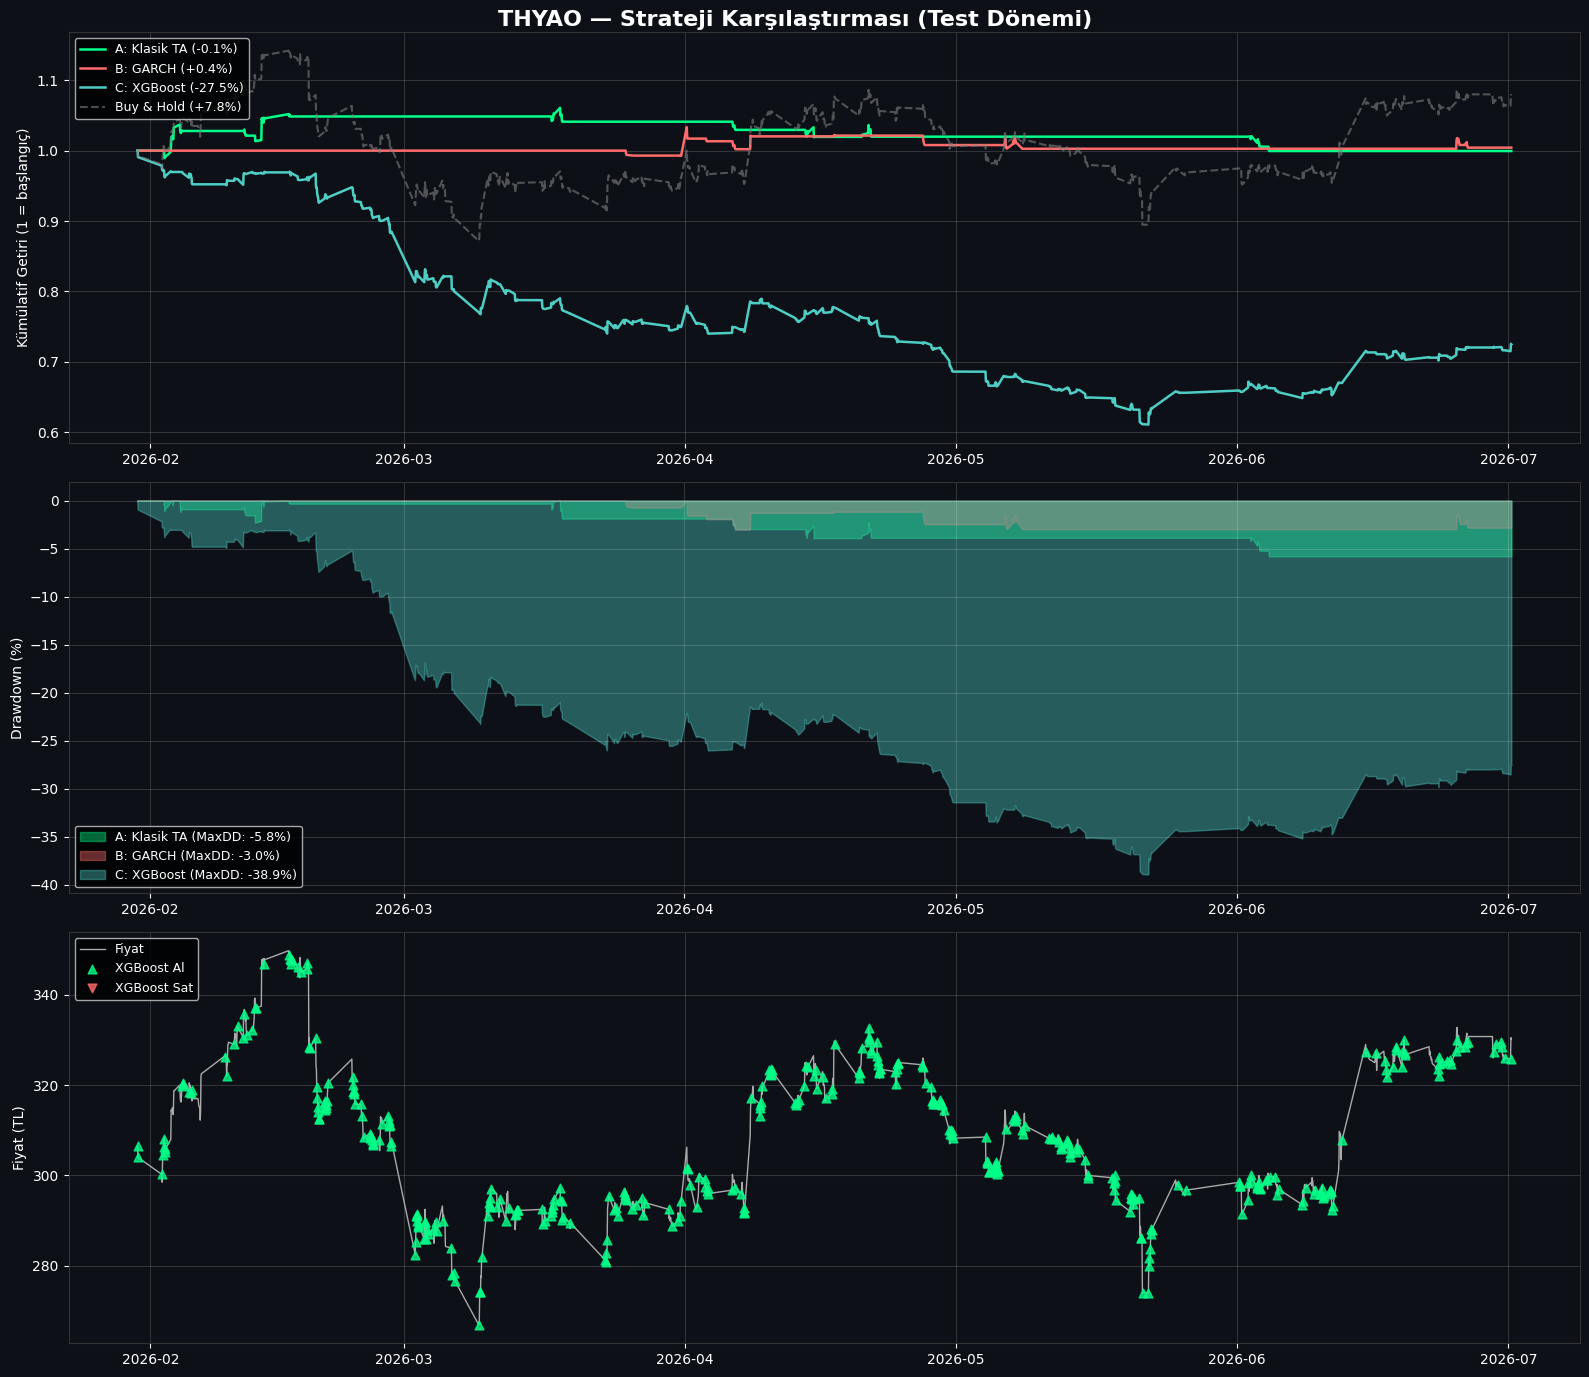

Grafik kaydedildi: strategy_comparison.png


In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), facecolor='#0d1117')
fig.suptitle(f'{TICKER} — Strateji Karşılaştırması (Test Dönemi)',
             fontsize=16, color='white', fontweight='bold', y=0.98)

# Panel 1: Kümülatif Getiri
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
for i, r in enumerate(results):
    cum = r['_data']['Cum_Return']
    ax1.plot(cum.index, cum.values, label=f"{r['Strateji']} ({r['Toplam Getiri %']:+.1f}%)",
             color=COLORS[i], linewidth=1.8)
# Buy & Hold
bh = results[0]['_data']['BH_Return']
ax1.plot(bh.index, bh.values, '--', color='gray', alpha=0.6,
         label=f"Buy & Hold ({results[0]['BH Getiri %']:+.1f}%)")
ax1.set_ylabel('Kümülatif Getiri (1 = başlangıç)', color='white')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(alpha=0.15)
ax1.tick_params(colors='white')
ax1.spines[['top','right','left','bottom']].set_color('#333')

# Panel 2: Drawdown
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
for i, r in enumerate(results):
    cum = r['_data']['Cum_Return']
    roll_max = cum.cummax()
    dd = (cum / roll_max - 1) * 100
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.4, color=COLORS[i],
                     label=f"{r['Strateji']} (MaxDD: {r['Max Drawdown %']:.1f}%)")
ax2.set_ylabel('Drawdown (%)', color='white')
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(alpha=0.15)
ax2.tick_params(colors='white')
ax2.spines[['top','right','left','bottom']].set_color('#333')

# Panel 3: Fiyat + Sinyaller (XGBoost)
ax3 = axes[2]
ax3.set_facecolor('#0d1117')
price_test = df.loc[df.index >= test_start, 'Close']
ax3.plot(price_test.index, price_test.values, color='#aaaaaa', linewidth=1, label='Fiyat')

# Al sinyalleri
buy_mask  = (sig_C == 1)  & (df.index >= test_start)
sell_mask = (sig_C == -1) & (df.index >= test_start)
ax3.scatter(df.index[buy_mask],  df.loc[buy_mask, 'Close'],
            marker='^', color='#00ff88', s=40, label='XGBoost Al', zorder=5, alpha=0.8)
ax3.scatter(df.index[sell_mask], df.loc[sell_mask, 'Close'],
            marker='v', color='#ff6b6b', s=40, label='XGBoost Sat', zorder=5, alpha=0.8)
ax3.set_ylabel('Fiyat (TL)', color='white')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(alpha=0.15)
ax3.tick_params(colors='white')
ax3.spines[['top','right','left','bottom']].set_color('#333')

for ax in axes:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_color('white')

plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Grafik kaydedildi: strategy_comparison.png')

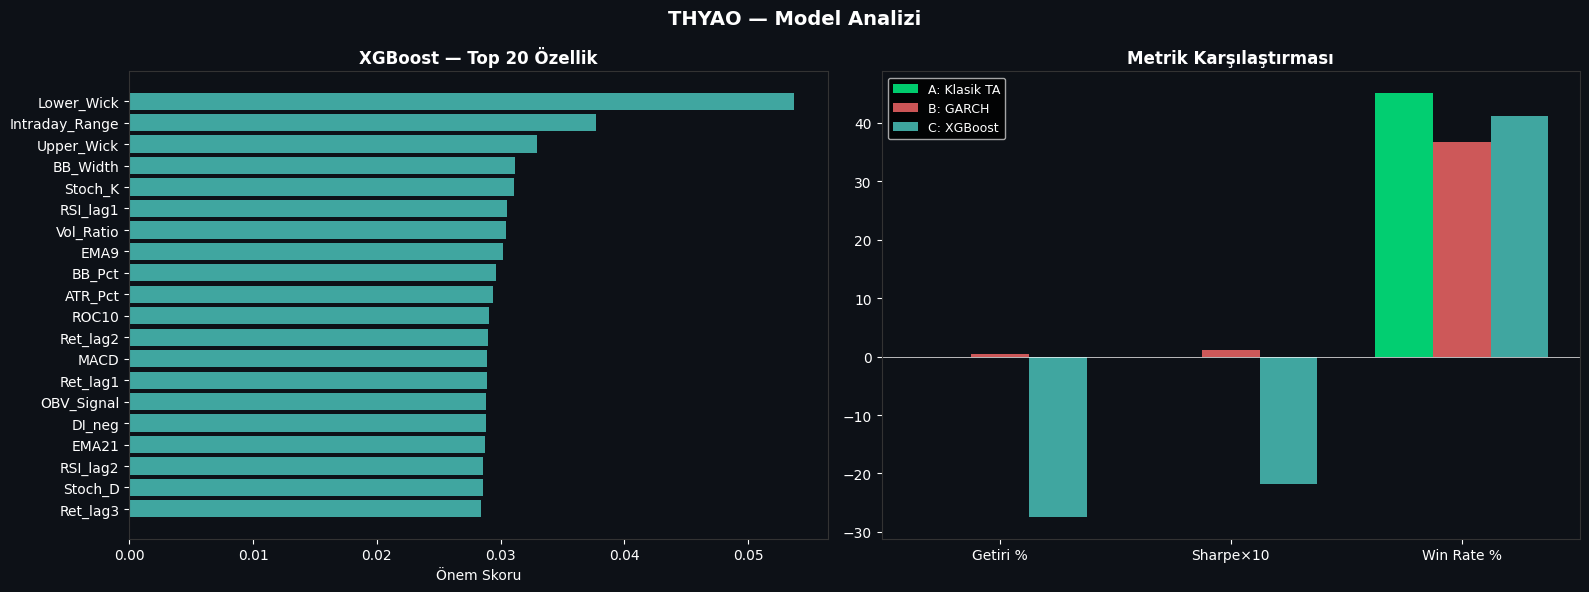

In [19]:
# XGBoost Özellik Önem Grafiği
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')

# Sol: Feature importance
top20 = feat_imp.head(20)
bars  = ax1.barh(top20.index[::-1], top20.values[::-1], color='#4ecdc4', alpha=0.8)
ax1.set_xlabel('Önem Skoru', color='white')
ax1.set_title('XGBoost — Top 20 Özellik', color='white', fontweight='bold')
ax1.set_facecolor('#0d1117')
ax1.tick_params(colors='white')
ax1.spines[['top','right','left','bottom']].set_color('#333')
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_color('white')

# Sağ: Metrik karşılaştırma (radar benzeri bar)
metrics  = ['Toplam Getiri %', 'Sharpe', 'Win Rate %']
names    = [r['Strateji'].split(':')[0] for r in results]
x        = np.arange(len(metrics))
width    = 0.25

for i, r in enumerate(results):
    vals = [r['Toplam Getiri %'], r['Sharpe']*10, r['Win Rate %']]
    ax2.bar(x + i*width, vals, width, label=r['Strateji'], color=COLORS[i], alpha=0.8)

ax2.set_xticks(x + width)
ax2.set_xticklabels(['Getiri %', 'Sharpe×10', 'Win Rate %'], color='white')
ax2.set_title('Metrik Karşılaştırması', color='white', fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_facecolor('#0d1117')
ax2.tick_params(colors='white')
ax2.spines[['top','right','left','bottom']].set_color('#333')
ax2.axhline(0, color='white', linewidth=0.5)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_color('white')

plt.suptitle(f'{TICKER} — Model Analizi', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## ⚡ 8. CANLI SİNYAL ÜRETİCİ — Şu Anki Bar İçin Tahmin

In [20]:
def generate_live_signal(ticker: str, exchange: str,
                         index_ticker: str, index_exchange: str,
                         interval: Interval, interval_str: str,
                         model, scaler, feature_cols: list) -> dict:
    """
    Gerçek zamanlı (veya en güncel) bar için tüm stratejilerin sinyalini üret.
    """
    print(f'\n{"═"*60}')
    print(f'CANLI SİNYAL — {ticker} | {interval_str} | {datetime.now().strftime("%Y-%m-%d %H:%M")}')
    print('═'*60)

    live_df = download_data(ticker, exchange, index_ticker, index_exchange,
                            interval, n_bars=500)
    live_df = build_features(live_df)

    last = live_df.dropna().iloc[-1]
    prev = live_df.dropna().iloc[-2]

    # ── Strateji A Sinyali ──────────────────────────────────────
    macd_cross = (last['MACD_Hist'] > 0) and (prev['MACD_Hist'] <= 0)
    rsi_ok     = 30 < last['RSI'] < 70
    trend_up   = last['EMA9'] > last['EMA21']
    vol_up     = last['Vol_Ratio'] > 1.0

    if macd_cross and rsi_ok and trend_up and vol_up:
        sig_a = 'AL  ▲'
    elif (last['MACD_Hist'] < 0 and prev['MACD_Hist'] >= 0) or (last['EMA9'] < last['EMA21']):
        sig_a = 'SAT ▼'
    else:
        sig_a = 'BEKLE ─'

    # ── Strateji C (XGBoost) Sinyali ───────────────────────────
    avail = [c for c in feature_cols if c in live_df.columns]
    last_features = live_df[avail].dropna().iloc[-1:]
    if len(last_features) > 0:
        last_sc  = scaler.transform(last_features)
        pred     = model.predict(last_sc)[0]
        proba    = model.predict_proba(last_sc)[0]
        sig_c    = f'AL  ▲ (güven: {proba[1]:.1%})' if pred == 1 else f'SAT ▼ (güven: {proba[0]:.1%})'
    else:
        sig_c = 'Yeterli veri yok'

    # ── Özet Çıktı ─────────────────────────────────────────────
    print(f'\nFiyat       : {last["Close"]:.2f} TL')
    print(f'RSI-14      : {last["RSI"]:.1f}')
    print(f'MACD Hist   : {last["MACD_Hist"]:.4f}')
    print(f'EMA9/21     : {last["EMA9"]:.2f} / {last["EMA21"]:.2f}')
    print(f'ATR %       : {last["ATR_Pct"]:.3%}')
    print(f'Hacim Oranı : {last["Vol_Ratio"]:.2f}x')
    print(f'ADX         : {last["ADX"]:.1f}')
    print(f'BB Pozisyon : {last["BB_Pct"]:.1%}')
    print()
    print(f'Strateji A (Klasik TA) : {sig_a}')
    print(f'Strateji C (XGBoost)   : {sig_c}')

    atr    = last['ATR']
    close  = last['Close']
    stop   = round(close - 1.5 * atr, 2)
    target = round(close + 2.5 * atr, 2)
    rr     = round((target - close) / (close - stop), 2) if close > stop else 'N/A'
    print(f'\n[SCALP PARAMETRELERİ]')
    print(f'  Giriş       : {close:.2f} TL')
    print(f'  Stop Loss   : {stop:.2f} TL  (-{(close-stop)/close:.1%})')
    print(f'  Hedef       : {target:.2f} TL  (+{(target-close)/close:.1%})')
    print(f'  Risk/Ödül   : 1:{rr}')

    return {'sig_a': sig_a, 'sig_c': sig_c, 'close': close,
            'stop': stop, 'target': target, 'rr': rr}


# Canlı sinyal üret
live = generate_live_signal(
    TICKER, EXCHANGE, INDEX_TKR, INDEX_EXCHANGE,
    TV_INTERVAL, INTERVAL_STR,
    xgb_model, xgb_scaler, FEATURE_COLS
)



════════════════════════════════════════════════════════════
CANLI SİNYAL — THYAO | 1h | 2026-07-01 08:37
════════════════════════════════════════════════════════════
TradingView misafir modda bağlandı ✓ (giriş yapılmadı)
▶ THYAO (BIST) indiriliyor...
▶ XU100 (BIST) indiriliyor...
✓ 500 bar yüklendi | 2026-04-13 → 2026-07-01

Fiyat       : 330.50 TL
RSI-14      : 61.7
MACD Hist   : 0.1065
EMA9/21     : 327.19 / 327.47
ATR %       : 0.591%
Hacim Oranı : 3.41x
ADX         : 23.3
BB Pozisyon : 108.2%

Strateji A (Klasik TA) : SAT ▼
Strateji C (XGBoost)   : AL  ▲ (güven: 60.9%)

[SCALP PARAMETRELERİ]
  Giriş       : 330.50 TL
  Stop Loss   : 327.57 TL  (-0.9%)
  Hedef       : 335.38 TL  (+1.5%)
  Risk/Ödül   : 1:1.67


## 🔄 11. GERİ BESLEME DÖNGÜSÜ — Öğrenilenleri Koda Uygula

In [21]:
# ══════════════════════════════════════════════════════════════════
#  GERİ BESLEME DÖNGÜSÜ — TAM AÇIKLAMALI
#
#  ÇALIŞMA AKIŞI:
#
#  ┌─ 1. TARAMA (örn. 10:00) ──────────────────────────────────────┐
#  │  Tüm hisseler taranır → her hissenin 4 motor skoru +         │
#  │  giriş fiyatı + tarama zamanı signal_log.json'a yazılır.     │
#  └───────────────────────────────────────────────────────────────┘
#           ↓  [Zaman geçer: 1h → 1 bar, 15m → 2 bar kadar bekle]
#  ┌─ 2. TARAMA (örn. 11:00) ──────────────────────────────────────┐
#  │  • validate_past_predictions(): 10:00 sinyallerinin          │
#  │    gerçek getirisini tvdatafeed'den çeker.                   │
#  │    "THYAO'ya AL dedi, gerçekten +1.2% kazandı mı?"          │
#  │  • update_motor_weights(): hangi motor daha isabetliydi?     │
#  │    İsabetli motor daha fazla ağırlık kazanır.               │
#  │  • Yeni tarama bu güncel ağırlıklarla çalışır.              │
#  └───────────────────────────────────────────────────────────────┘
#
#  SONUÇ: Her tarama döngüsü bir öncekinin hatalarından öğrenir.
# ══════════════════════════════════════════════════════════════════

SIGNAL_LOG_FILE = MEMORY_DIR / 'signal_log.json'
WEIGHTS_FILE    = MEMORY_DIR / 'motor_weights.json'
DEFAULT_WEIGHTS = {'ta': 0.35, 'xgb': 0.35, 'garch': 0.15, 'pattern': 0.15}

# ── Interval başına: kaç bar sonra ölç, kaç dakika bekle ─────────
#  Örn: 1h intervalinde 3 bar ilerisi ölçülür (= 3 saat sonra),
#       minimum bekleme 3h×60 = 180 dakika.
INTERVAL_CONFIG = {
    '1m' : {'horizon': 5,  'min_wait_min': 5},
    '5m' : {'horizon': 4,  'min_wait_min': 20},
    '15m': {'horizon': 3,  'min_wait_min': 45},
    '30m': {'horizon': 3,  'min_wait_min': 90},
    '1h' : {'horizon': 3,  'min_wait_min': 180},
    '2h' : {'horizon': 3,  'min_wait_min': 360},
    '4h' : {'horizon': 3,  'min_wait_min': 720},
    '1d' : {'horizon': 3,  'min_wait_min': 4320},   # 3 gün
    '1W' : {'horizon': 2,  'min_wait_min': 20160},
    '1M' : {'horizon': 1,  'min_wait_min': 86400},
}


def load_signal_log() -> list:
    if SIGNAL_LOG_FILE.exists():
        with open(SIGNAL_LOG_FILE) as f:
            return json.load(f)
    return []

def save_signal_log(log: list):
    with open(SIGNAL_LOG_FILE, 'w') as f:
        json.dump(log, f, indent=2, default=str)

def load_motor_weights() -> dict:
    if WEIGHTS_FILE.exists():
        with open(WEIGHTS_FILE) as f:
            w = json.load(f)
        if all(k in w for k in DEFAULT_WEIGHTS):
            return w
    return DEFAULT_WEIGHTS.copy()

def save_motor_weights(weights: dict):
    with open(WEIGHTS_FILE, 'w') as f:
        json.dump(weights, f, indent=2)


def log_scan_predictions(scan_df: pd.DataFrame, interval_str: str) -> int:
    """
    Tarama sonuçlarını signal_log.json'a yaz.
    Bir sonraki çalıştırmada gerçek getiriyle karşılaştırılacak.
    """
    cfg     = INTERVAL_CONFIG.get(interval_str, {'horizon': 3, 'min_wait_min': 180})
    horizon = cfg['horizon']
    log     = load_signal_log()
    count   = 0

    for _, row in scan_df.iterrows():
        log.append({
            'tarih'      : datetime.now().isoformat(),
            'ticker'     : row['Hisse'],
            'fiyat'      : row['Fiyat'],
            'interval'   : interval_str,
            'horizon'    : horizon,
            'ta_score'   : float(row.get('TA', 0)),
            'xgb_prob'   : float(row.get('YZ_%', 50)) / 100,
            'garch_dir'  : (1  if 'Düşük' in str(row.get('GARCH',''))
                            else -1 if 'Yüksek' in str(row.get('GARCH',''))
                            else 0),
            'pat_ret'    : float(str(row.get('Patern','0%')).replace('%','').replace('+','') or 0) / 100,
            'composite'  : float(row.get('Skor', 5)),
            'sinyal'     : str(row.get('Sinyal', '')),
            'gercek_ret' : None,
            'dogrulandi' : False,
        })
        count += 1

    save_signal_log(log)
    return count


def validate_past_predictions(tv_interval: Interval,
                               interval_str: str) -> pd.DataFrame:
    """
    Daha önce kaydedilen sinyallerin gerçek getirisini ölç.
    Timestamp ile eşleşme yapar (fiyat yakınlığı değil → hatasız).
    """
    log = load_signal_log()
    if not log:
        return pd.DataFrame()

    cfg          = INTERVAL_CONFIG.get(interval_str, {'horizon':3,'min_wait_min':180})
    min_wait_min = cfg['min_wait_min']

    tv           = get_tv_client()
    updated      = 0
    pending      = sum(1 for e in log if not e.get('dogrulandi'))

    if pending == 0:
        print('Tüm geçmiş sinyaller zaten doğrulanmış.')
        validated = [e for e in log if e.get('dogrulandi')]
        return pd.DataFrame(validated) if validated else pd.DataFrame()

    print(f'Doğrulanacak sinyal: {pending} adet')
    ticker_cache = {}   # aynı hisseyi birden fazla kez çekme

    for entry in log:
        if entry.get('dogrulandi'):
            continue

        tarih   = datetime.fromisoformat(entry['tarih'])
        gecen_m = (datetime.now() - tarih).total_seconds() / 60

        if gecen_m < min_wait_min:
            # Henüz yeterli süre geçmedi
            kalan = int(min_wait_min - gecen_m)
            continue

        # Gerçek fiyatı çek (cache'den al)
        tkr = entry['ticker']
        if tkr not in ticker_cache:
            try:
                raw = tv.get_hist(symbol=tkr, exchange='BIST',
                                  interval=tv_interval, n_bars=100)
                if raw is not None and not raw.empty:
                    price_df = tv_to_df(raw)
                    # Timezone-naive index garantisi
                    price_df.index = pd.to_datetime(price_df.index)
                    if price_df.index.tz is not None:
                        price_df.index = price_df.index.tz_localize(None)
                    ticker_cache[tkr] = price_df
                else:
                    ticker_cache[tkr] = None
            except Exception:
                ticker_cache[tkr] = None

        price_df = ticker_cache.get(tkr)
        if price_df is None:
            continue

        # Sinyal zamanına en yakın bar'ı bul (timestamp eşleşmesi)
        signal_time = tarih
        time_diffs  = abs(price_df.index - signal_time)
        entry_idx   = time_diffs.argmin()

        # horizon bar sonrasının kapanışını al
        exit_idx = min(entry_idx + entry['horizon'], len(price_df) - 1)
        if exit_idx <= entry_idx:
            continue

        entry_price = price_df['Close'].iloc[entry_idx]
        exit_price  = price_df['Close'].iloc[exit_idx]
        ret         = (exit_price - entry_price) / entry_price

        entry['gercek_ret']  = round(float(ret), 5)
        entry['dogrulandi']  = True
        entry['giris_fiyat'] = round(float(entry_price), 2)
        entry['cikis_fiyat'] = round(float(exit_price), 2)
        entry['dogrulama_t'] = datetime.now().isoformat()
        updated += 1

    save_signal_log(log)

    validated = [e for e in log if e.get('dogrulandi')]
    print(f'Bu turda doğrulanan: {updated} | Toplam doğrulanmış: {len(validated)}')
    return pd.DataFrame(validated) if validated else pd.DataFrame()


def update_motor_weights(validated_df: pd.DataFrame,
                          min_records: int = 15) -> dict:
    """
    Son N sinyale göre her motorun yön isabetini hesapla.
    Softmax re-weighting + %70/%30 harmanlama ile güncelle.
    """
    current = load_motor_weights()

    if validated_df is None or len(validated_df) < min_records:
        n = len(validated_df) if validated_df is not None else 0
        print(f'Yeterli veri yok ({n}/{min_records}). '
              f'Mevcut ağırlıklar korunuyor: {current}')
        return current

    df = validated_df.copy()
    df['gercek_yon'] = np.sign(df['gercek_ret'].astype(float))

    # Her motorun yön isabeti (1=doğru, 0=yanlış)
    df['ta_hit']    = ((df['ta_score'].astype(float)  / 9 - 0.5) * df['gercek_yon'] > 0).astype(float)
    df['xgb_hit']   = ((df['xgb_prob'].astype(float)  - 0.5)     * df['gercek_yon'] > 0).astype(float)
    df['garch_hit'] = ( df['garch_dir'].astype(float)             * df['gercek_yon'] > 0).astype(float)
    df['pat_hit']   = ( df['pat_ret'].astype(float)               * df['gercek_yon'] > 0).astype(float)

    recent = df.tail(30)
    raw_scores = {
        'ta'     : recent['ta_hit'].mean(),
        'xgb'    : recent['xgb_hit'].mean(),
        'garch'  : recent['garch_hit'].mean(),
        'pattern': recent['pat_hit'].mean(),
    }

    vals    = np.array(list(raw_scores.values()))
    exp_v   = np.exp((vals - vals.mean()) * 5)
    w_new   = dict(zip(raw_scores.keys(), (exp_v / exp_v.sum()).round(4).tolist()))

    # %70 yeni + %30 eski → ani sıçramayı önle
    blended = {k: round(0.70*w_new[k] + 0.30*current[k], 4) for k in current}
    total   = sum(blended.values())
    blended = {k: round(v/total, 4) for k, v in blended.items()}
    save_motor_weights(blended)

    # ── Özet rapor ───────────────────────────────────────────────
    W = 58
    print('\n' + '═'*W)
    print('  MOTOR AĞIRLIK GÜNCELLEMESİ')
    print('─'*W)
    print(f'  {"Motor":<10} {"Önceki":>7} {"İsabet%":>8} {"Yeni":>7} {"Değişim":>9}')
    print('  ' + '─'*46)
    for k in current:
        old, new = current[k], blended[k]
        hit = raw_scores[k] * 100
        chg = new - old
        arrow = '▲' if chg > 0.005 else ('▼' if chg < -0.005 else '─')
        bar   = '█' * int(new * 20)
        print(f'  {k:<10} {old:>7.4f} {hit:>7.1f}% {new:>7.4f} {chg:>+8.4f} {arrow}  {bar}')
    print('─'*W)

    best   = max(raw_scores, key=raw_scores.get)
    worst  = min(raw_scores, key=raw_scores.get)
    n_val  = len(df)
    n_win  = (df['gercek_yon'] > 0).sum()
    print(f'  Değerlendirilen sinyal : {n_val}')
    print(f'  Gerçekleşen yükseliş  : {n_win} ({n_win/n_val*100:.1f}%)')
    print(f'  En isabetli motor     : {best} (%{raw_scores[best]*100:.1f})')
    print(f'  En yanılgılı motor    : {worst} (%{raw_scores[worst]*100:.1f})')
    print('═'*W)

    return blended


# ── DÖNGÜYÜ ÇALIŞTIR ─────────────────────────────────────────────
print('ADIM 1 — Geçmiş tahminler doğrulanıyor...')
print(f'(Bekleme eşiği: {INTERVAL_CONFIG.get(INTERVAL_STR,{}).get("min_wait_min","?")} dakika)')

validated_df = validate_past_predictions(TV_INTERVAL, INTERVAL_STR)

print('\nADIM 2 — Motor ağırlıkları güncelleniyor...')
updated_weights = update_motor_weights(validated_df)
print(f'\nGüncel ağırlıklar: {updated_weights}')


ADIM 1 — Geçmiş tahminler doğrulanıyor...
(Bekleme eşiği: 180 dakika)

ADIM 2 — Motor ağırlıkları güncelleniyor...
Yeterli veri yok (0/15). Mevcut ağırlıklar korunuyor: {'ta': 0.35, 'xgb': 0.35, 'garch': 0.15, 'pattern': 0.15}

Güncel ağırlıklar: {'ta': 0.35, 'xgb': 0.35, 'garch': 0.15, 'pattern': 0.15}


In [22]:
# ══════════════════════════════════════════════════════════════════
#  ÖĞRENILMIŞ AĞIRLIKLARLA _composite_score() — her taramadan önce çalışır
# ══════════════════════════════════════════════════════════════════

_motor_w = load_motor_weights()

def _composite_score(ta_s, xgb_p, garch_s, pat_s, weights=None):
    w = weights or _motor_w
    return round((w['ta']      * (ta_s / 9.0)     +
                  w['xgb']     * xgb_p             +
                  w['garch']   * ((garch_s + 1)/2) +
                  w['pattern'] * ((pat_s  + 1)/2)) * 10, 2)

W = 52
print('Adaptif _composite_score() aktif.')
print(f'{"Motor":<12} {"Ağırlık":>8}  {"Görsel Bar"}')
print('─'*W)
for k, v in _motor_w.items():
    bar = '█' * int(v * 40)
    print(f'  {k:<10} {v:>8.4f}  {bar}')
print('─'*W)
toplam = sum(_motor_w.values())
print(f'  {"TOPLAM":<10} {toplam:>8.4f}  (1.0000 = tam)')

# Kaç sinyal birikmeli güncelleme için bekleniyor?
log = load_signal_log()
validated = sum(1 for e in log if e.get('dogrulandi'))
pending   = sum(1 for e in log if not e.get('dogrulandi'))
print(f'\nSinyal günlüğü: {validated} doğrulanmış | {pending} bekliyor')
if validated < 15:
    print(f'Not: {15-validated} sinyal daha doğrulanınca ağırlıklar güncellenecek.')


Adaptif _composite_score() aktif.
Motor         Ağırlık  Görsel Bar
────────────────────────────────────────────────────
  ta           0.3500  ██████████████
  xgb          0.3500  ██████████████
  garch        0.1500  ██████
  pattern      0.1500  ██████
────────────────────────────────────────────────────
  TOPLAM       1.0000  (1.0000 = tam)

Sinyal günlüğü: 0 doğrulanmış | 0 bekliyor
Not: 15 sinyal daha doğrulanınca ağırlıklar güncellenecek.


## 🔍 9. BIST-100 TARAYICI — En İyi Fırsatları Bul

In [23]:
import concurrent.futures, time, requests

# ══════════════════════════════════════════════════════════════════
#  BIST TAM LİSTESİ — TradingView Scanner API'den dinamik çek
#  tvdatafeed ile aynı veri kaynağı → her zaman güncel
# ══════════════════════════════════════════════════════════════════

def fetch_bist_symbols() -> list:
    """
    TradingView Scanner API'den tüm BIST hisselerini çeker.
    Üyelik veya giriş gerektirmez — açık endpoint.
    Döner: [('THYAO','BIST'), ('AKBNK','BIST'), ...]
    """
    url     = 'https://scanner.tradingview.com/turkey/scan'
    headers = {
        'Content-Type' : 'application/json',
        'User-Agent'   : 'Mozilla/5.0',
        'Origin'       : 'https://www.tradingview.com',
        'Referer'      : 'https://www.tradingview.com/',
    }
    payload = {
        'filter'  : [],
        'options' : {'lang': 'en'},
        'symbols' : {'query': {'types': ['stock']}, 'tickers': []},
        'columns' : ['name', 'description', 'type', 'subtype', 'exchange'],
        'sort'    : {'sortBy': 'name', 'sortOrder': 'asc'},
        'range'   : [0, 2000],
    }

    try:
        resp = requests.post(url, json=payload, headers=headers, timeout=20)
        resp.raise_for_status()
        data    = resp.json()
        symbols = []
        for row in data.get('data', []):
            ticker = row.get('d', [None])[0]   # 'name' sütunu
            if ticker and isinstance(ticker, str):
                # Format: "BIST:THYAO" → "THYAO"
                clean = ticker.split(':')[-1].strip()
                if clean and clean.isalpha() and 2 <= len(clean) <= 7:
                    symbols.append((clean, 'BIST'))
        symbols = list(dict.fromkeys(symbols))  # tekrar kaldır, sıra koru
        print(f'TradingView Scanner: {len(symbols)} BIST hissesi çekildi ✓')
        return symbols

    except Exception as e:
        print(f'TradingView API hatası: {e}')
        print('Yedek kaynak deneniyor: KAP / isyatirim...')
        return _fetch_bist_fallback()


def _fetch_bist_fallback() -> list:
    """
    Ana kaynak başarısız olursa birden fazla yedek dene.
    """
    sources = [
        # Kaynak 1: isyatirim.com.tr — tam hisse listesi
        (
            'https://www.isyatirim.com.tr/analysis/fundamental/equity/index',
            lambda html: [
                (s.strip(), 'BIST')
                for tbl in pd.read_html(html)
                for col in tbl.select_dtypes('object').columns
                for s in tbl[col].dropna().astype(str)
                if s.strip().isalpha() and 2 <= len(s.strip()) <= 7
            ]
        ),
        # Kaynak 2: Mynet finans
        (
            'https://finans.mynet.com/borsa/hisseler/',
            lambda html: [
                (s.strip(), 'BIST')
                for tbl in pd.read_html(html)
                for col in tbl.select_dtypes('object').columns
                for s in tbl[col].dropna().astype(str)
                if s.strip().isalpha() and 2 <= len(s.strip()) <= 7
            ]
        ),
    ]

    hdrs = {'User-Agent': 'Mozilla/5.0'}
    for url, parser in sources:
        try:
            r = requests.get(url, headers=hdrs, timeout=15)
            symbols = parser(r.text)
            unique  = list(dict.fromkeys(symbols))
            if len(unique) > 50:
                print(f'Yedek kaynak ({url[:40]}...): {len(unique)} hisse ✓')
                return unique
        except Exception:
            continue

    # Son çare: bilinen çekirdek liste (sadece büyük ve likit hisseler)
    print('Tüm kaynaklar başarısız, minimum çekirdek liste kullanılıyor.')
    core = [
        'THYAO','AKBNK','GARAN','SISE','EREGL','KCHOL','SAHOL','YKBNK','HALKB',
        'VAKBN','TUPRS','TCELL','BIMAS','FROTO','TOASO','KOZAL','PGSUS','TAVHL',
        'ASELS','EKGYO','ARCLK','ENKAI','TKFEN','PETKM','AEFES','CCOLA','MGROS',
        'SOKM','AKGRT','ANHYT','AYGAZ','BUCIM','BTCIM','CIMSA','DOHOL','GUBRF',
        'NUHCM','OTKAR','TTKOM','TTRAK',
    ]
    return [(s, 'BIST') for s in core]


# ─── LİSTEYİ ÇEK ─────────────────────────────────────────────────
BIST_ALL = fetch_bist_symbols()
print(f'Toplam taranacak hisse: {len(BIST_ALL)}')


# ══════════════════════════════════════════════════════════════════
#  4-MODEL PARALEL TARAYICI (değişmedi)
# ══════════════════════════════════════════════════════════════════

_xgb_model  = joblib.load(MODEL_FILE)  if MODEL_FILE.exists()  else None
_xgb_scaler = joblib.load(SCALER_FILE) if SCALER_FILE.exists() else None
_xgb_cols   = [c for c in FEATURE_COLS if c in df.columns]
_ref_rets   = df['Log_Return'].dropna().values[-20:]
_ref_norm   = (_ref_rets - _ref_rets.mean()) / (_ref_rets.std() + 1e-9)


def _ta_score(last, prev):
    score, labels = 0, []
    checks = [
        (last['RSI'] > 50,                   '+RSI>50'),
        (last['MACD_Hist'] > 0,              '+MACD+'),
        (last['EMA9']  > last['EMA21'],      '+EMA9>21'),
        (last['EMA21'] > last['SMA50'],      '+EMA21>50'),
        (last['Vol_Ratio'] > 1.2,            '+Hacim'),
        (last['ADX'] > 25,                   '+ADX'),
        (last['ROC5'] > 0,                   '+ROC5'),
        (last['BB_Pct'] > 0.5,               '+BB'),
        (last['Stoch_K'] > last['Stoch_D'],  '+Stoch'),
    ]
    for cond, lbl in checks:
        if cond:
            score += 1; labels.append(lbl)
    return score, labels


def _xgb_score(d):
    if _xgb_model is None or _xgb_scaler is None:
        return 0.5, 'MODEL_YOK'
    try:
        avail    = [c for c in _xgb_cols if c in d.columns]
        last_row = d[avail].dropna().iloc[-1:]
        if len(last_row) == 0:
            return 0.5, 'VERİ_YOK'
        proba = _xgb_model.predict_proba(_xgb_scaler.transform(last_row))[0][1]
        lbl   = (f'YZ:AL({proba:.0%})'       if proba >= 0.65 else
                 f'YZ:ZAYIFAL({proba:.0%})'  if proba >= 0.50 else
                 f'YZ:ZAYIFSAT({proba:.0%})' if proba >= 0.35 else
                 f'YZ:SAT({proba:.0%})')
        return proba, lbl
    except Exception:
        return 0.5, 'YZ:HATA'


def _garch_lite_score(d):
    try:
        rets   = d['Log_Return'].dropna()
        if len(rets) < 30:
            return 0, 'VOL:YETERSİZ'
        pct = rets.rolling(10).std().rank(pct=True).iloc[-1]
        if pct < 0.30:
            return  1, f'GARCH:DüşükVol({pct:.0%})'
        elif pct > 0.70:
            return -1, f'GARCH:YüksekVol({pct:.0%})'
        else:
            return  0, f'GARCH:OrtaVol({pct:.0%})'
    except Exception:
        return 0, 'VOL:HATA'


def _pattern_score(d, lookback=20):
    try:
        rets = d['Log_Return'].dropna().values
        if len(rets) < lookback + 10:
            return 0, 0.0, 'PAT:YETERSİZ'
        window = rets[-lookback:]
        norm   = (window - window.mean()) / (window.std() + 1e-9)
        dist   = np.linalg.norm(_ref_norm - norm[:len(_ref_norm)])
        future_rets = [
            np.sum(rets[i:i+3])
            for i in range(lookback, len(rets) - lookback - 3)
            if np.linalg.norm(norm - (lambda w: (w-w.mean())/(w.std()+1e-9))
                              (rets[i-lookback:i])) < dist * 1.3
        ]
        if len(future_rets) < 3:
            return 0, 0.0, 'PAT:EŞLEŞMEYok'
        avg = np.mean(future_rets)
        if avg > 0.005:
            return  1, avg, f'PAT:Yukari({avg*100:+.1f}%)'
        elif avg < -0.005:
            return -1, avg, f'PAT:Asagi({avg*100:+.1f}%)'
        else:
            return  0, avg, f'PAT:Notr({avg*100:+.1f}%)'
    except Exception:
        return 0, 0.0, 'PAT:HATA'


def _composite_score(ta_s, xgb_p, garch_s, pat_s, weights=None):
    w = weights or (load_motor_weights() if 'load_motor_weights' in dir() else
                    {'ta':0.35,'xgb':0.35,'garch':0.15,'pattern':0.15})
    return round((w['ta']      * (ta_s/9.0)        +
                  w['xgb']     * xgb_p              +
                  w['garch']   * ((garch_s+1)/2)    +
                  w['pattern'] * ((pat_s+1)/2)) * 10, 2)


def _scan_single_full(args):
    tkr, exch, tv_interval, n_bars = args
    try:
        tv  = TvDatafeed()
        raw = tv.get_hist(symbol=tkr, exchange=exch,
                          interval=tv_interval, n_bars=n_bars)
        if raw is None or len(raw) < 60:
            return None
        d    = build_features(tv_to_df(raw).assign(Endeks_Close=lambda x: x['Close']))
        dna  = d.dropna()
        if len(dna) < 30:
            return None
        last, prev = dna.iloc[-1], dna.iloc[-2]

        ta_s,  ta_lbl          = _ta_score(last, prev)
        xgb_p, xgb_lbl         = _xgb_score(d)
        gs,    g_lbl            = _garch_lite_score(d)
        ps,    pr, p_lbl        = _pattern_score(d)
        comp  = _composite_score(ta_s, xgb_p, gs, ps)

        signal = ('🟢🟢 GÜÇLÜ AL' if comp >= 7.0 else
                  '🟢 AL'         if comp >= 5.5 else
                  '🟡 BEKLE'      if comp >= 4.5 else
                  '🔴 SAT'        if comp >= 3.0 else
                  '🔴🔴 GÜÇLÜ SAT')

        return {
            'Hisse'    : tkr,
            'Fiyat'    : round(last['Close'], 2),
            'Skor'     : comp,
            'Sinyal'   : signal,
            'TA'       : ta_s,
            'YZ_%'     : round(xgb_p * 100, 1),
            'GARCH'    : g_lbl.split(':')[1] if ':' in g_lbl else g_lbl,
            'Patern'   : f'{pr*100:+.2f}%',
            'RSI'      : round(last['RSI'], 1),
            'ATR_%'    : round(last['ATR_Pct'] * 100, 2),
            'HacimOran': round(last['Vol_Ratio'], 2),
            'ADX'      : round(last['ADX'], 1),
            'Stop'     : round(last['Close'] - 1.5 * last['ATR'], 2),
            'Hedef'    : round(last['Close'] + 2.5 * last['ATR'], 2),
        }
    except Exception:
        return None


def scan_all_bist_full(symbol_list, tv_interval=Interval.in_daily,
                       n_bars=300, max_workers=8, top_n=25):
    args_list = [(s, e, tv_interval, n_bars) for s, e in symbol_list]
    total, records, errors, done = len(args_list), [], 0, 0
    t0 = time.time()
    print(f'4-Model Tarama: {total} hisse | {max_workers} paralel iş parçacığı')
    print('Motorlar: TA + XGBoost YZ + GARCH Rejim + Patern Benzerliği')
    print('─' * 65)
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(_scan_single_full, a): a[0] for a in args_list}
        for future in concurrent.futures.as_completed(futures):
            done += 1
            res = future.result()
            if res:
                records.append(res)
            else:
                errors += 1
            if done % 75 == 0 or done == total:
                print(f'  {done}/{total} ({done/total*100:.0f}%) | '
                      f'Analiz: {len(records)} | Atlanan: {errors} | {time.time()-t0:.0f}s')
    full_df = pd.DataFrame(records).sort_values('Skor', ascending=False)
    print(f'\nTamamlandı: {len(records)} hisse ({time.time()-t0:.0f}s)')
    return full_df.head(top_n), full_df


# ─── ÇALIŞTIR ────────────────────────────────────────────────────
FULL_SCAN     = True
SCAN_INTERVAL = Interval.in_daily

scan_list = BIST_ALL if FULL_SCAN else BIST_ALL[:100]

top_df, full_df = scan_all_bist_full(
    scan_list, tv_interval=SCAN_INTERVAL,
    n_bars=350, max_workers=8, top_n=25,
)

# ─── SONUÇLARI GÖSTER ────────────────────────────────────────────
W2 = 85
print('\n' + '═'*W2)
print(f'  BIST TAM TARAMA — EN GÜÇLÜ 25 HİSSE  [{datetime.now().strftime("%d.%m.%Y %H:%M")}]')
print('═'*W2)
cols = ['Hisse','Fiyat','Skor','Sinyal','TA','YZ_%','GARCH','Patern',
        'RSI','HacimOran','ADX','Stop','Hedef']
print(top_df[cols].to_string(index=False))

print('\nSKOR (0-10): >=7.0 GÜÇLÜ AL | >=5.5 AL | >=4.5 BEKLE | >=3.0 SAT | <3.0 GÜÇLÜ SAT')
print('YZ_%: Yapay Zekanın yükseliş tahmini | GARCH: Oynaklık rejimi | Patern: Beklenen 3-bar getiri')

print('\nSİNYAL DAĞILIMI:')
for sinyal, cnt in full_df['Sinyal'].value_counts().items():
    bar = '█' * max(1, cnt // 6)
    print(f'  {sinyal:<22}: {cnt:>4} hisse ({cnt/len(full_df)*100:5.1f}%)  {bar}')

combo = full_df[(full_df['HacimOran'] > 1.3) & (full_df['YZ_%'] >= 60)].nlargest(10, 'Skor')
if len(combo) > 0:
    print('\nYÜKSEK HACİM + YÜKSEK YZ GÜVEN:')
    print(combo[['Hisse','Fiyat','Skor','Sinyal','YZ_%','HacimOran','GARCH','Patern']].to_string(index=False))


log_scan_predictions(full_df, INTERVAL_STR)

TradingView Scanner: 606 BIST hissesi çekildi ✓
Toplam taranacak hisse: 606
4-Model Tarama: 606 hisse | 8 paralel iş parçacığı
Motorlar: TA + XGBoost YZ + GARCH Rejim + Patern Benzerliği
─────────────────────────────────────────────────────────────────


  75/606 (12%) | Analiz: 12 | Atlanan: 63 | 6s


  150/606 (25%) | Analiz: 24 | Atlanan: 126 | 13s


  225/606 (37%) | Analiz: 36 | Atlanan: 189 | 19s


  300/606 (50%) | Analiz: 48 | Atlanan: 252 | 25s


  375/606 (62%) | Analiz: 68 | Atlanan: 307 | 33s


  450/606 (74%) | Analiz: 77 | Atlanan: 373 | 38s


  525/606 (87%) | Analiz: 88 | Atlanan: 437 | 44s


  600/606 (99%) | Analiz: 100 | Atlanan: 500 | 50s
  606/606 (100%) | Analiz: 105 | Atlanan: 501 | 52s

Tamamlandı: 105 hisse (52s)

═════════════════════════════════════════════════════════════════════════════════════
  BIST TAM TARAMA — EN GÜÇLÜ 25 HİSSE  [01.07.2026 08:38]
═════════════════════════════════════════════════════════════════════════════════════
Hisse      Fiyat   Skor      Sinyal  TA    YZ_%          GARCH Patern     RSI  HacimOran     ADX       Stop      Hedef
DSTKF  3622.5000 7.6000 🟢🟢 GÜÇLÜ AL   8 42.6000   DüşükVol(9%) +2.65% 86.3000     2.1900 45.1000  3392.9400  4005.0900
IEYHO   152.0000 7.5900 🟢🟢 GÜÇLÜ AL   8 63.6000   OrtaVol(38%) +2.84% 94.6000     2.9000 77.9000   145.6500   162.5800
KRONT    25.0200 7.5300 🟢🟢 GÜÇLÜ AL   8 62.0000   OrtaVol(57%) +0.64% 74.5000     2.2100 22.7000    23.2600    27.9600
KTLEV   174.5000 7.5000 🟢🟢 GÜÇLÜ AL   6 61.8000  DüşükVol(21%) +3.07% 66.3000     0.6400 46.2000   160.8100   197.3100
AKSUE    39.0400 6.9800        🟢 AL   8 46

105

## 🔎 10. BENZERLİK PATERNİ TARAYICISI (DTW Tabanlı)

In [24]:
from scipy.spatial.distance import euclidean

def find_similar_patterns(df: pd.DataFrame, lookback: int = 20,
                           n_matches: int = 5) -> pd.DataFrame:
    """
    Son 'lookback' barı referans al, geçmişte en benzer desenleri bul.
    Normalize edilmiş Öklid mesafesi kullanır (hızlı DTW yerine).
    Eşleşme sonrası getiriyi döndürür → istatistiksel ön görü.
    """
    prices = df['Close'].values
    rets   = df['Log_Return'].dropna().values

    # Referans desen: son lookback barın normalize getirileri
    ref_window = rets[-lookback:]
    ref_norm   = (ref_window - ref_window.mean()) / (ref_window.std() + 1e-9)

    matches = []
    horizon = 5   # ileriye kaç bar bak

    for i in range(lookback, len(rets) - lookback - horizon):
        window = rets[i-lookback:i]
        norm   = (window - window.mean()) / (window.std() + 1e-9)
        dist   = np.linalg.norm(ref_norm - norm)   # L2
        future_ret = np.sum(rets[i:i+horizon])      # sonraki horizon bar getirisi
        matches.append({'idx': i, 'dist': dist,
                        'date': df.index[i].date(),
                        f'Sonraki {horizon} bar': round(future_ret * 100, 2)})

    res = pd.DataFrame(matches).sort_values('dist').head(n_matches)
    res = res[['date', 'dist', f'Sonraki {horizon} bar']]
    res.columns = ['Tarih', 'Mesafe', f'Sonraki {horizon}bar Getiri %']

    avg_fwd = res[f'Sonraki {horizon}bar Getiri %'].mean()
    direction = 'YUKARI ▲' if avg_fwd > 0 else 'AŞAĞI ▼'

    print(f'\n[PATERİN ANALİZİ] Son {lookback} bar ile en benzer {n_matches} geçmiş desen:')
    print(res.to_string(index=False))
    print(f'\n→ Ortalama sonraki {horizon} bar getiri tahmini: {avg_fwd:+.2f}% ({direction})')

    return res


pattern_res = find_similar_patterns(df.dropna(), lookback=20, n_matches=5)


[PATERİN ANALİZİ] Son 20 bar ile en benzer 5 geçmiş desen:
     Tarih  Mesafe  Sonraki 5bar Getiri %
2025-06-24  2.7737                 1.5600
2026-04-01  2.8366                -2.4800
2025-05-12  2.9994                -0.4900
2024-11-25  3.0342                -2.0200
2026-01-28  3.1228                -0.4200

→ Ortalama sonraki 5 bar getiri tahmini: -0.77% (AŞAĞI ▼)


## 📋 12. HERKES İÇİN ANLAŞILIR KARAR RAPORU — "Ne Yapmalıyım?"

In [25]:
# ══════════════════════════════════════════════════════════════════
#  ANLAŞILIR KARAR PANELİ
#  Teknik bilgisi olmayan birine de ne yapması gerektiğini söyler.
# ══════════════════════════════════════════════════════════════════

def interpret_rsi(rsi):
    if rsi > 70:
        return ('🔴 AŞIRI ALINDI', 'Fiyat çok hızlı yükseldi, düzeltme gelebilir. Yeni alım için bekle.')
    elif rsi > 55:
        return ('🟡 GÜÇLÜ BÖLGE',  'Fiyat yükseliş momentumunda ama dikkatli ol.')
    elif rsi > 45:
        return ('🟢 NÖTR',          'Ne çok yüksek ne çok düşük. Trend yönü belirleyici.')
    elif rsi > 30:
        return ('🟡 ZAYIF BÖLGE',   'Fiyat düşüş baskısı altında.')
    else:
        return ('🔴 AŞIRI SATILDI', 'Fiyat çok hızlı düştü, toparlanma gelebilir. Dikkatli al.')

def interpret_macd(hist):
    if hist > 0.01:
        return ('🟢 AL YÖNÜNDE',  'Kısa vadeli yükseliş ivmesi var.')
    elif hist > 0:
        return ('🟡 ZAYIF AL',    'Çok küçük bir yükseliş işareti, doğrulama bekle.')
    elif hist > -0.01:
        return ('🟡 ZAYIF SAT',   'Çok küçük bir düşüş işareti.')
    else:
        return ('🔴 SAT YÖNÜNDE', 'Kısa vadeli düşüş ivmesi var.')

def interpret_adx(adx):
    if adx > 40:
        return ('💪 ÇOK GÜÇLÜ TREND', 'Piyasa güçlü bir yönde ilerliyor. Trend takipçi stratejiler işe yarar.')
    elif adx > 25:
        return ('✅ TREND VAR',        'Belirgin bir yön var, sinyal güvenilirliği yüksek.')
    elif adx > 20:
        return ('⚠️ ZAYIF TREND',      'Trend oluşuyor, henüz net değil.')
    else:
        return ('❌ YATAY PİYASA',     'Belirgin yön yok. Scalp sinyalleri daha az güvenilir.')

def interpret_vol_ratio(vr):
    if vr > 2.0:
        return ('🔥 PATLAMACI HACİM', 'Normal günün 2 katı hacim var! Büyük bir hareket yaklaşıyor olabilir.')
    elif vr > 1.3:
        return ('📈 YÜKSEK HACİM',    'Ortalamanın üzerinde hacim. Hareket destekli.')
    elif vr > 0.7:
        return ('➡️  NORMAL HACİM',   'Sıradan bir gün. Sinyaller orta güvenilirlikte.')
    else:
        return ('📉 DÜŞÜK HACİM',     'Hacim yok, piyasa uyuşuk. Sahte hareketlere dikkat.')

def interpret_strategy_score(winrate, ret):
    if winrate >= 60 and ret > 5:
        return '🏆 MÜKEMMEL — Bu strateji hem çok kazandırıyor hem doğru tahmin ediyor.'
    elif winrate >= 55 and ret > 0:
        return '✅ İYİ — Karlı ve güvenilir. Canlı kullanıma uygundur.'
    elif winrate >= 50 and ret > 0:
        return '⚠️ ORTA — Karlı ama tahminlerde bazen yanılıyor. Dikkatli kullan.'
    elif ret > 0:
        return '🤔 ZAYIF TAHMIN — Para kazandı ama şansa bağlı olabilir.'
    else:
        return '❌ KÖTÜ — Bu periyotta para kaybettirdi. Kullanma.'

def get_overall_signal(sig_a_str, sig_c_str, adx_val):
    a_bull = 'AL' in sig_a_str
    c_bull = sig_c_str and 'AL' in sig_c_str
    a_bear = 'SAT' in sig_a_str
    c_bear = sig_c_str and 'SAT' in sig_c_str
    trend_ok = adx_val > 20

    if a_bull and c_bull and trend_ok:
        return ('🟢🟢🟢 GÜÇLÜ AL', 'Her iki sistem de ALIŞ diyor ve piyasada belirgin bir yükseliş trendi var. '
                                   'Bu, sinyal kalitesinin en yüksek olduğu durumdur.')
    elif a_bull and c_bull:
        return ('🟢🟢 AL (Trend Zayıf)', 'Her iki sistem alış diyor ancak trend gücü düşük. '
                                          'Daha küçük pozisyonla gir.')
    elif (a_bull or c_bull) and not (a_bear or c_bear):
        return ('🟡 ZAYIF AL', 'Sistemlerden sadece biri alış diyor. '
                                'Ek onay beklemeden işlem açma.')
    elif a_bear and c_bear and trend_ok:
        return ('🔴🔴🔴 GÜÇLÜ SAT/BEKLE', 'Her iki sistem de SATIŞ diyor ve belirgin bir düşüş trendi var. '
                                           'Pozisyon alma, mevcut pozisyonu kapat.')
    elif a_bear or c_bear:
        return ('🔴 SAT/BEKLE', 'En az bir sistem satiş diyor. '
                                 'Yeni alım yapma, temkinli ol.')
    else:
        return ('⚪ BEKLE', 'Sistemler net bir sinyal üretmiyor. '
                             'Fırsatı kaçırmak yerine beklemek daha akıllıcadır.')


# ── Mevcut bar değerlerini al ───────────────────────────────────
last_bar   = df.dropna().iloc[-1]
rsi_lbl,   rsi_desc   = interpret_rsi(last_bar['RSI'])
macd_lbl,  macd_desc  = interpret_macd(last_bar['MACD_Hist'])
adx_lbl,   adx_desc   = interpret_adx(last_bar['ADX'])
vol_lbl,   vol_desc   = interpret_vol_ratio(last_bar['Vol_Ratio'])

# A sinyali (son bar)
sig_a_last = sig_A.loc[last_bar.name] if last_bar.name in sig_A.index else 0
sig_a_txt  = 'AL ▲' if sig_a_last == 1 else ('SAT ▼' if sig_a_last == -1 else 'BEKLE ─')

# XGBoost son tahmin
avail_c = [c for c in FEATURE_COLS if c in df.columns]
last_feat = df[avail_c].dropna().iloc[-1:]
if len(last_feat) > 0:
    lf_sc      = xgb_scaler_opt.transform(last_feat)
    xgb_pred   = xgb_model_opt.predict(lf_sc)[0]
    xgb_proba  = xgb_model_opt.predict_proba(lf_sc)[0]
    sig_c_txt  = f'AL ▲ (%{xgb_proba[1]*100:.0f} güven)' if xgb_pred == 1 else f'SAT ▼ (%{xgb_proba[0]*100:.0f} güven)'
else:
    sig_c_txt = 'Veri yok'

overall_lbl, overall_desc = get_overall_signal(sig_a_txt, sig_c_txt, last_bar['ADX'])

# Scalp parametreleri
close_px = last_bar['Close']
atr_px   = last_bar['ATR']
stop_px  = round(close_px - 1.5 * atr_px, 2)
tgt_px   = round(close_px + 2.5 * atr_px, 2)
rr_ratio = round((tgt_px - close_px) / max(close_px - stop_px, 0.01), 2)

# ── EKRANA YAZ ─────────────────────────────────────────────────
W = 68
print('╔' + '═'*W + '╗')
print('║' + f'  {TICKER} — GÜNCEL PİYASA DURUMU VE KARAR RAPORU'.center(W) + '║')
print('║' + f'  {datetime.now().strftime("%d %B %Y, %H:%M")} | Zaman Dilimi: {INTERVAL_STR}'.center(W) + '║')
print('╠' + '═'*W + '╣')

print('║' + '  📊 GÖSTERGE ANALİZİ'.ljust(W) + '║')
print('╠' + '─'*W + '╣')
print(f'║  RSI (Aşırı Alım/Satım Göstergesi)   : {rsi_lbl:<30}║')
print(f'║    → {rsi_desc:<{W-5}}║')
print(f'║  MACD (Momentum Göstergesi)           : {macd_lbl:<30}║')
print(f'║    → {macd_desc:<{W-5}}║')
print(f'║  ADX (Trend Gücü)                     : {adx_lbl:<30}║')
print(f'║    → {adx_desc:<{W-5}}║')
print(f'║  Hacim (İşlem Yoğunluğu)              : {vol_lbl:<30}║')
print(f'║    → {vol_desc:<{W-5}}║')

print('╠' + '═'*W + '╣')
print('║' + '  🤖 STRATEJİ KARARLARI'.ljust(W) + '║')
print('╠' + '─'*W + '╣')
print(f'║  Klasik TA Sistemi (Kural Tabanlı)    : {sig_a_txt:<30}║')
print(f'║  Yapay Zeka (XGBoost, Optimize)       : {sig_c_txt:<30}║')
print('╠' + '═'*W + '╣')
print('║' + f'  GENEL KARAR: {overall_lbl}'.ljust(W) + '║')
print(f'║  {overall_desc[:W-3]:<{W-2}}║')
if len(overall_desc) > W-3:
    print(f'║  {overall_desc[W-3:2*(W-3)]:<{W-2}}║')
print('╠' + '═'*W + '╣')
print('║' + '  💰 SCALP İŞLEM ÖNERİSİ (ATR Tabanlı)'.ljust(W) + '║')
print('╠' + '─'*W + '╣')
print(f'║  Şu anki fiyat   : {close_px:.2f} TL{"":<{W-26}}║')
print(f'║  Stop Loss       : {stop_px:.2f} TL  ← Buraya gelirse zararı kes!{"":<{W-55}}║')
print(f'║  Hedef Fiyat     : {tgt_px:.2f} TL  ← Burada kar al{"":<{W-47}}║')
print(f'║  Risk/Ödül Oranı : 1:{rr_ratio}  ← 1 birim riske {rr_ratio} birim kazanç{"":<{W-55}}║')
print('╠' + '═'*W + '╣')
print('║' + '  📈 BACKTEST ÖZETI (Geçmiş Test Sonuçları)'.ljust(W) + '║')
print('╠' + '─'*W + '╣')

all_res_display = [res_A, res_B, res_C, res_C_opt]
for r in all_res_display:
    wr   = r['Win Rate %']
    ret  = r['Toplam Getiri %']
    yorum = interpret_strategy_score(wr, ret)
    name  = r['Strateji'][:25]
    print(f'║  {name:<26}: Getiri {ret:+6.1f}% | Win Rate {wr:5.1f}% ║')
    print(f'║    → {yorum[:W-6]:<{W-6}}║')

print('╠' + '═'*W + '╣')
print('║' + f'  🏆 ŞAMPİYON: {champ_full["Strateji"]}'.ljust(W) + '║')

# Öğrenme istatistiği
wf_avg = wf_results['Doğruluk %'].mean()
print('╠' + '═'*W + '╣')
print('║' + '  🧠 MODELİN ÖĞRENMESİ'.ljust(W) + '║')
print('╠' + '─'*W + '╣')
print(f'║  Walk-Forward Ortalama Doğruluk : %{wf_avg:.1f}{"":<{W-38}}║')
wf_interp = ('✅ Model güvenilir tahmin yapıyor.' if wf_avg >= 55
             else '⚠️ Tahminler sınırda, daha fazla veriye ihtiyaç var.')
print(f'║  Yorum: {wf_interp:<{W-9}}║')
print(f'║  Toplam geçmiş çalıştırma       : {len(history)}{"":<{W-37}}║')
print(f'║  Model trend durumu             : {performance_trend(history)[:30]:<30}║')
print('╚' + '═'*W + '╝')


╔════════════════════════════════════════════════════════════════════╗
║             THYAO — GÜNCEL PİYASA DURUMU VE KARAR RAPORU           ║
║                01 July 2026, 08:38 | Zaman Dilimi: 1h              ║
╠════════════════════════════════════════════════════════════════════╣
║  📊 GÖSTERGE ANALİZİ                                                ║
╠────────────────────────────────────────────────────────────────────╣
║  RSI (Aşırı Alım/Satım Göstergesi)   : 🟡 GÜÇLÜ BÖLGE                 ║
║    → Fiyat yükseliş momentumunda ama dikkatli ol.                   ║
║  MACD (Momentum Göstergesi)           : 🟢 AL YÖNÜNDE                  ║
║    → Kısa vadeli yükseliş ivmesi var.                               ║
║  ADX (Trend Gücü)                     : ⚠️ ZAYIF TREND                ║
║    → Trend oluşuyor, henüz net değil.                               ║
║  Hacim (İşlem Yoğunluğu)              : 🔥 PATLAMACI HACİM             ║
║    → Normal günün 2 katı hacim var! Büyük bir hareket yaklaşı

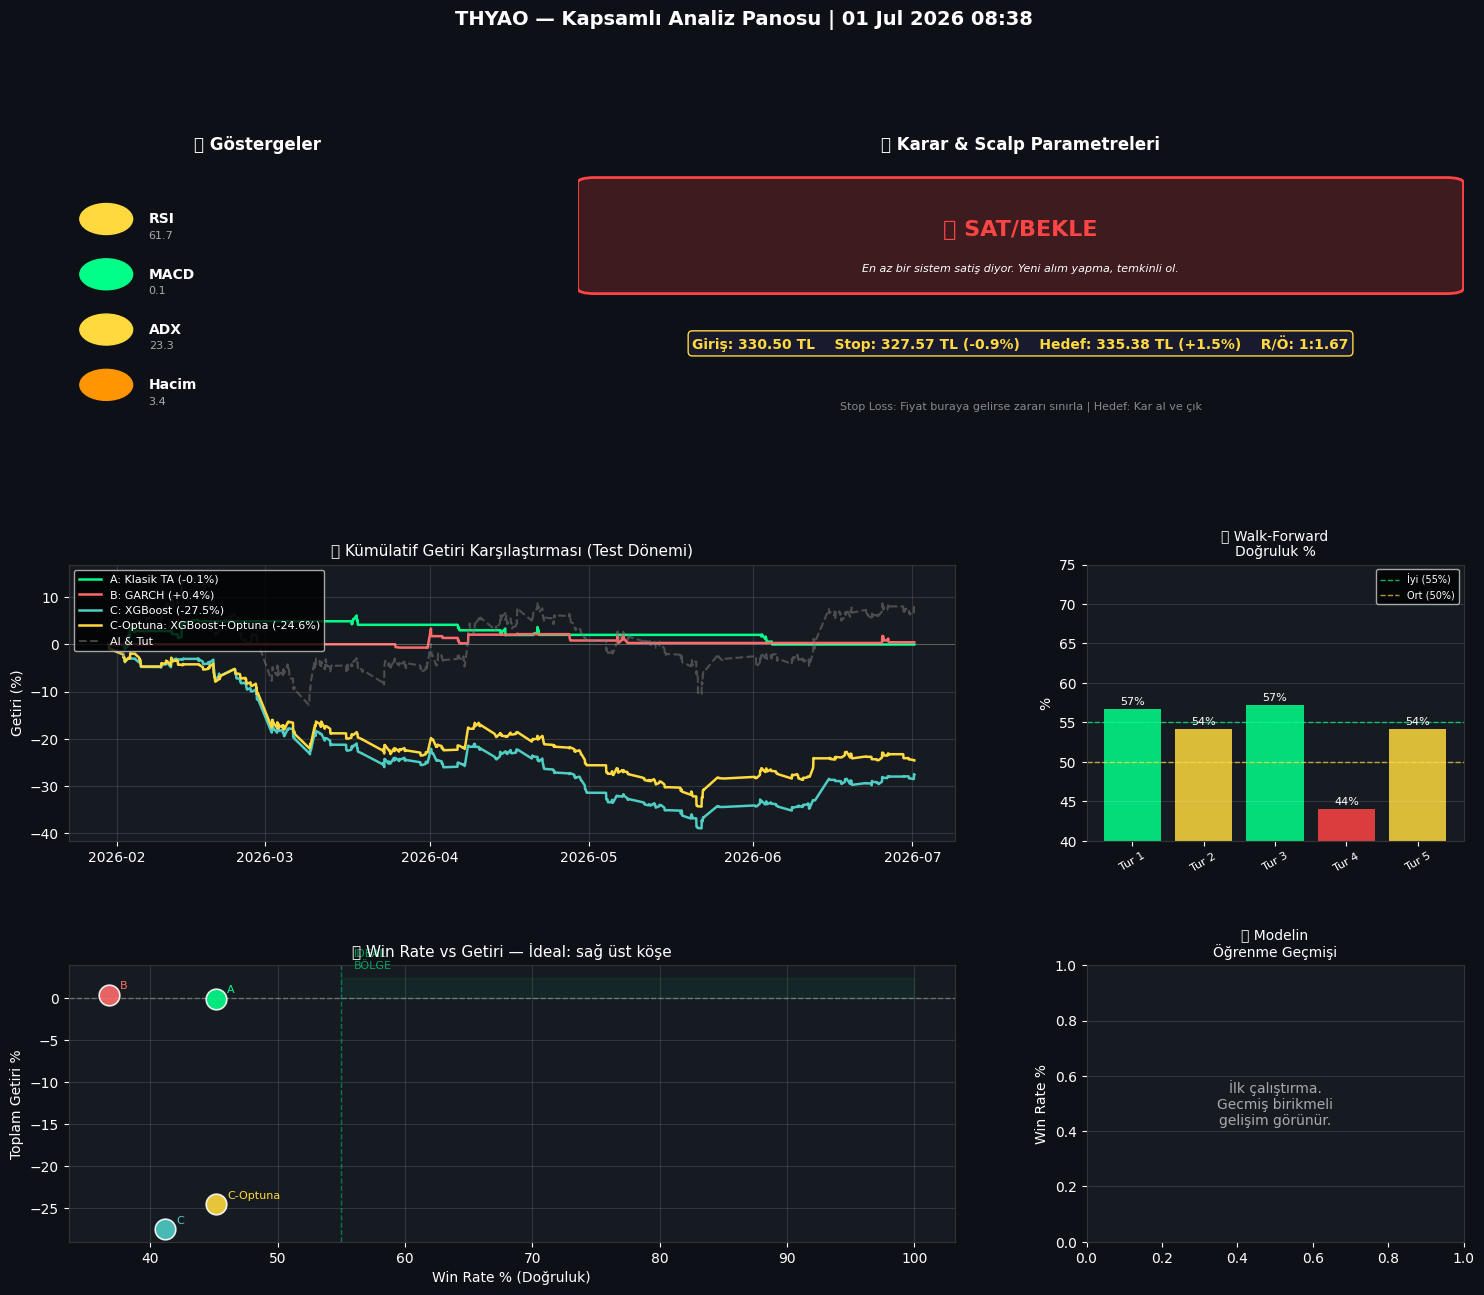

Dashboard kaydedildi: dashboard.png


In [26]:
# ══════════════════════════════════════════════════════════════════
#  GÖRSEL DASHBOARD — Tek bakışta her şeyi anlayan grafik
# ══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 14), facecolor='#0d1117')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Gösterge Trafik Işıkları ─────────────────────────
ax_lights = fig.add_subplot(gs[0, 0])
ax_lights.set_facecolor('#0d1117')
ax_lights.set_xlim(0, 4); ax_lights.set_ylim(0, 5)
ax_lights.axis('off')
ax_lights.set_title('📊 Göstergeler', color='white', fontsize=12, fontweight='bold', pad=10)

indicators = [
    ('RSI', last_bar['RSI'], rsi_lbl),
    ('MACD', last_bar['MACD_Hist'], macd_lbl),
    ('ADX', last_bar['ADX'], adx_lbl),
    ('Hacim', last_bar['Vol_Ratio'], vol_lbl),
]
color_map = {'🟢': '#00ff88', '🔴': '#ff4444', '🟡': '#ffd93d',
             '✅': '#00ff88', '❌': '#ff4444', '⚠': '#ffd93d',
             '💪': '#00ff88', '📈': '#00ff88', '📉': '#ff4444',
             '➡': '#aaaaaa', '🔥': '#ff9500'}

for i, (name, val, label) in enumerate(indicators):
    first_emoji = label[0]
    col = next((v for k, v in color_map.items() if k in first_emoji), '#aaaaaa')
    y = 4 - i
    circle = plt.Circle((0.4, y), 0.28, color=col, zorder=3)
    ax_lights.add_patch(circle)
    ax_lights.text(0.85, y,    name,  color='white', fontsize=10, va='center', fontweight='bold')
    ax_lights.text(0.85, y-0.3, f'{val:.1f}', color='#aaaaaa', fontsize=8, va='center')

# ── Panel 2: Genel Karar Kartı ─────────────────────────────────
ax_decision = fig.add_subplot(gs[0, 1:])
ax_decision.set_facecolor('#0d1117')
ax_decision.axis('off')
ax_decision.set_title('🎯 Karar & Scalp Parametreleri', color='white', fontsize=12, fontweight='bold', pad=10)

decision_color = '#00ff88' if 'AL' in overall_lbl else ('#ff4444' if 'SAT' in overall_lbl else '#ffd93d')
fancy_box = mpatches.FancyBboxPatch((0.02, 0.55), 0.96, 0.38,
    boxstyle='round,pad=0.02', facecolor=decision_color+'33',
    edgecolor=decision_color, linewidth=2, transform=ax_decision.transAxes)
ax_decision.add_patch(fancy_box)
ax_decision.text(0.5, 0.76, overall_lbl, color=decision_color,
                 ha='center', va='center', fontsize=16, fontweight='bold',
                 transform=ax_decision.transAxes)
ax_decision.text(0.5, 0.62, overall_desc[:80], color='white',
                 ha='center', va='center', fontsize=8, style='italic',
                 transform=ax_decision.transAxes, wrap=True)

# Scalp parametreleri
params_txt = (
    f'Giriş: {close_px:.2f} TL    '
    f'Stop: {stop_px:.2f} TL (-{(close_px-stop_px)/close_px:.1%})    '
    f'Hedef: {tgt_px:.2f} TL (+{(tgt_px-close_px)/close_px:.1%})    '
    f'R/Ö: 1:{rr_ratio}'
)
ax_decision.text(0.5, 0.35, params_txt, color='#ffd93d',
                 ha='center', va='center', fontsize=10, fontweight='bold',
                 transform=ax_decision.transAxes,
                 bbox=dict(boxstyle='round', facecolor='#1a1a2e', edgecolor='#ffd93d'))

ax_decision.text(0.5, 0.12,
    'Stop Loss: Fiyat buraya gelirse zararı sınırla | Hedef: Kar al ve çık',
    color='#888888', ha='center', va='center', fontsize=8, transform=ax_decision.transAxes)

# ── Panel 3: Kümülatif Getiri (tüm stratejiler) ───────────────
ax_ret = fig.add_subplot(gs[1, :2])
ax_ret.set_facecolor('#161b22')
ax_ret.set_title('📈 Kümülatif Getiri Karşılaştırması (Test Dönemi)', color='white', fontsize=11)
for i, r in enumerate([res_A, res_B, res_C, res_C_opt]):
    cum = r['_data']['Cum_Return']
    ax_ret.plot(cum.index, (cum.values - 1)*100,
                label=f"{r['Strateji']} ({r['Toplam Getiri %']:+.1f}%)",
                color=COLORS[i], linewidth=1.8)
bh = res_A['_data']['BH_Return']
ax_ret.plot(bh.index, (bh.values-1)*100, '--', color='gray', alpha=0.5, label='Al & Tut')
ax_ret.axhline(0, color='white', linewidth=0.5, alpha=0.3)
ax_ret.set_ylabel('Getiri (%)', color='white')
ax_ret.legend(fontsize=8, loc='upper left')
ax_ret.grid(alpha=0.12); ax_ret.tick_params(colors='white')
for sp in ax_ret.spines.values(): sp.set_color('#333')
for lb in ax_ret.get_xticklabels()+ax_ret.get_yticklabels(): lb.set_color('white')

# ── Panel 4: Walk-Forward Doğruluk Çubuğu ─────────────────────
ax_wf = fig.add_subplot(gs[1, 2])
ax_wf.set_facecolor('#161b22')
ax_wf.set_title('🧠 Walk-Forward\nDoğruluk %', color='white', fontsize=10)
wf_colors = ['#00ff88' if v >= 55 else ('#ffd93d' if v >= 50 else '#ff4444')
             for v in wf_results['Doğruluk %']]
bars = ax_wf.bar(wf_results['Tur'], wf_results['Doğruluk %'], color=wf_colors, alpha=0.85)
ax_wf.axhline(55, color='#00ff88', linewidth=1, linestyle='--', alpha=0.7, label='İyi (55%)')
ax_wf.axhline(50, color='#ffd93d', linewidth=1, linestyle='--', alpha=0.7, label='Ort (50%)')
ax_wf.set_ylim(40, 75); ax_wf.set_ylabel('%', color='white')
ax_wf.legend(fontsize=7); ax_wf.grid(alpha=0.12, axis='y')
ax_wf.tick_params(colors='white'); ax_wf.tick_params(axis='x', labelrotation=30, labelsize=8)
for sp in ax_wf.spines.values(): sp.set_color('#333')
for lb in ax_wf.get_xticklabels()+ax_wf.get_yticklabels(): lb.set_color('white')
for bar, val in zip(bars, wf_results['Doğruluk %']):
    ax_wf.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
               f'{val:.0f}%', ha='center', va='bottom', color='white', fontsize=8)

# ── Panel 5: Strateji Karşılaştırma (Win Rate vs Getiri) ──────
ax_scatter = fig.add_subplot(gs[2, :2])
ax_scatter.set_facecolor('#161b22')
ax_scatter.set_title('🎯 Win Rate vs Getiri — İdeal: sağ üst köşe', color='white', fontsize=11)
for i, r in enumerate([res_A, res_B, res_C, res_C_opt]):
    ax_scatter.scatter(r['Win Rate %'], r['Toplam Getiri %'],
                       s=220, color=COLORS[i], zorder=5, alpha=0.9,
                       edgecolors='white', linewidth=1.2)
    ax_scatter.annotate(r['Strateji'].split(':')[0],
                        (r['Win Rate %'], r['Toplam Getiri %']),
                        textcoords='offset points', xytext=(8, 4),
                        color=COLORS[i], fontsize=8)
ax_scatter.axvline(55, color='#00ff88', linestyle='--', alpha=0.4, linewidth=1)
ax_scatter.axhline(0,  color='white',   linestyle='--', alpha=0.3, linewidth=1)
ax_scatter.fill_betweenx(
    [max(0, min(r['Toplam Getiri %'] for r in [res_A,res_B,res_C,res_C_opt])-2),
     max(r['Toplam Getiri %'] for r in [res_A,res_B,res_C,res_C_opt])+2],
    55, 100, alpha=0.05, color='#00ff88')
ax_scatter.text(56, ax_scatter.get_ylim()[1]*0.9, 'İDEAL\nBÖLGE', color='#00ff88',
                fontsize=8, alpha=0.6)
ax_scatter.set_xlabel('Win Rate % (Doğruluk)', color='white')
ax_scatter.set_ylabel('Toplam Getiri %', color='white')
ax_scatter.grid(alpha=0.12); ax_scatter.tick_params(colors='white')
for sp in ax_scatter.spines.values(): sp.set_color('#333')
for lb in ax_scatter.get_xticklabels()+ax_scatter.get_yticklabels(): lb.set_color('white')

# ── Panel 6: Geçmiş Öğrenme Eğrisi ───────────────────────────
ax_hist = fig.add_subplot(gs[2, 2])
ax_hist.set_facecolor('#161b22')
ax_hist.set_title('📚 Modelin\nÖğrenme Geçmişi', color='white', fontsize=10)
if len(history) >= 2:
    runs   = [f"#{i+1}" for i in range(len(history))]
    wr_hist= [h.get('xgb_opt_winrate', h.get('xgb_winrate', 50)) for h in history]
    ax_hist.plot(runs, wr_hist, color='#c77dff', marker='o', linewidth=2, markersize=8)
    ax_hist.axhline(55, color='#00ff88', linestyle='--', alpha=0.5, linewidth=1)
    ax_hist.set_ylim(40, 75)
    ax_hist.fill_between(runs, wr_hist, 50, alpha=0.2,
                         color='#00ff88' if wr_hist[-1] >= 50 else '#ff4444')
    for i, (x, y) in enumerate(zip(runs, wr_hist)):
        ax_hist.annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                         xytext=(0, 6), ha='center', color='white', fontsize=8)
else:
    ax_hist.text(0.5, 0.5, 'İlk çalıştırma.\nGecmiş birikmeli\ngelişim görünür.',
                 ha='center', va='center', color='#aaaaaa', fontsize=10,
                 transform=ax_hist.transAxes)
ax_hist.set_ylabel('Win Rate %', color='white')
ax_hist.grid(alpha=0.12, axis='y'); ax_hist.tick_params(colors='white')
for sp in ax_hist.spines.values(): sp.set_color('#333')
for lb in ax_hist.get_xticklabels()+ax_hist.get_yticklabels(): lb.set_color('white')

fig.suptitle(
    f'{TICKER} — Kapsamlı Analiz Panosu | {datetime.now().strftime("%d %b %Y %H:%M")}',
    color='white', fontsize=14, fontweight='bold', y=0.99
)
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Dashboard kaydedildi: dashboard.png')
